# ♟️ Chess Human Move Predictor
### Predicting moves of 2200–2600 ELO players · Lichess Elite Dataset

---

## Overview

This notebook builds a **learning-to-rank model** that predicts which chess move a human player (ELO 2200–2600) is most likely to make in any given position, using games from Lichess (October 2019).

| | |
|---|---|
| **Task** | Rank all legal moves by how likely a human would play them |
| **Approach** | 1 positive sample (played move) + N negative samples (legal but unplayed) per position |
| **Features** | 768-dim board + 24 semantic move + 10 metadata = **802 total** |
| **Evaluation** | Top-1 / Top-3 accuracy on held-out games (game-level split) |

---

## Notebook Structure

| # | Section | Description |
|---|---|---|
| 1 | **Setup** | Imports, config, load PGN data |
| 2 | **Game-Level EDA** | ELO distributions, openings, game lengths |
| 3 | **Position Extraction** | Extract all board positions from games |
| 4 | **Move-Level EDA** | Move frequencies, legal move counts |
| 5 | **Position Features EDA** | Material balance, castling rights, game phase |
| 6 | **Feature Engineering** | `board_to_array`, `move_to_semantic_array`, metadata features |
| 7 | **Feature Analysis** | Audit zero/constant features, record live columns |
| 8 | **Dataset Creation** | Game-level train/test split → build labeled datasets |
| 9 | **Dataset EDA** | Validate label balance, sparsity, position integrity |
| 10 | **Model Training & Evaluation** | All models with honest overfit test per model |
| 11 | **Model Comparison** | Side-by-side Top-1 / Top-3 / gap summary |
| 12 | **Save Best Model** | Persist final ranker |


---
# 1. Setup & Data Loading

## 1.1 Imports & Global Config

In [1]:
import chess
import chess.pgn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter, defaultdict
import warnings

from sklearn.model_selection import train_test_split

# Visualization settings
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


## 1.2 Load Filtered Games

Reads games from the Lichess Elite PGN and keeps only games where **both players** are in the 2200–2600 ELO range.


In [2]:
pgn_path = "lichess_elite_2019-10.pgn"
min_elo=2200 
max_elo=2600 
max_games=15000

games = []

with open(pgn_path) as f:
    while True:
        game = chess.pgn.read_game(f)
        if game is None:
            break
        
        try:
            w_elo = int(game.headers.get("WhiteElo", 0))
            b_elo = int(game.headers.get("BlackElo", 0))
        except:
            continue
        
        if min_elo <= w_elo <= max_elo and min_elo <= b_elo <= max_elo:
            games.append(game)
            
            if len(games) >= max_games:
                break

print(f"\nTotal filtered games loaded: {len(games)}")
print(f"ELO range: 2200-2600")


Total filtered games loaded: 15000
ELO range: 2200-2600


## 1.3 Sample Game Inspection

In [3]:
# Display first game headers and moves
sample_game = games[0]

print("Sample Game Headers:")
print("=" * 50)
for key, value in sample_game.headers.items():
    print(f"{key:20s}: {value}")

print("\nGame Moves:")
print("=" * 50)
print(sample_game.mainline_moves())

# Count moves
move_count = sum(1 for _ in sample_game.mainline_moves())
print(f"\nTotal moves in this game: {move_count}")

Sample Game Headers:
Event               : Rated Blitz game
Site                : ?
Date                : 2019.10.01
Round               : -
White               : Chesssknock
Black               : www68
Result              : 1-0
WhiteElo            : 2482
BlackElo            : 2473
ECO                 : A43
Opening             : Old Benoni Defense
TimeControl         : 180+0
UTCDate             : 2019.10.01
UTCTime             : 00:00:12
Termination         : Time forfeit
WhiteRatingDiff     : +7
BlackRatingDiff     : -7

Game Moves:
1. d4 c5 2. Nf3 cxd4 3. Nxd4 d5 4. g3 e5 5. Nb3 Nc6 6. Bg2 Be6 7. O-O Be7 8. a4 Nf6 9. a5 a6 10. Nc3 h6 11. Bd2 O-O 12. Na4 Nd7 13. Be1 d4 14. f4 Bxb3 15. cxb3 exf4 16. Rxf4 Bg5 17. Rf1 Rc8 18. Kh1 Be3 19. b4 Qg5 20. Qb3 Qb5 21. g4 Qxe2 22. Bg3 Nf6 23. h3 Qb5 24. Nc5 Qxb4 25. Qxb4 Nxb4 26. Nxb7 Nc2 27. Rad1 Nb4 28. Nd6 Rc5 29. Nf5 Rxa5 30. Nxd4 Ra2 31. Nf5 Bc5 32. Be5 Ne8 33. Bc3 h5 34. gxh5 Ra5 35. h6 gxh6 36. Nxh6+ Kh7 37. Nxf7

Total moves in this game:

---
# 2. Game-Level Exploratory Data Analysis

## 2.1 Extract Game Metadata

In [4]:
metadata = []

for i, game in enumerate(tqdm(games, desc="Extracting metadata")):
    # Count moves
    move_count = sum(1 for _ in game.mainline_moves())

    if move_count < 8 or move_count > 200:
        continue
        
    # Extract headers
    try:
        white_elo = int(game.headers.get("WhiteElo", 0))
        black_elo = int(game.headers.get("BlackElo", 0))
    except:
        white_elo = 0
        black_elo = 0
    
    metadata.append({
        'game_id': i,
        'white': game.headers.get("White", "Unknown"),
        'black': game.headers.get("Black", "Unknown"),
        'result': game.headers.get("Result", "*"),
        'white_elo': white_elo,
        'black_elo': black_elo,
        'avg_elo': (white_elo + black_elo) / 2,
        'elo_diff': white_elo - black_elo,
        'eco': game.headers.get("ECO", "Unknown"),
        'opening': game.headers.get("Opening", "Unknown"),
        'time_control': game.headers.get("TimeControl", "Unknown"),
        'termination': game.headers.get("Termination", "Unknown"),
        'date': game.headers.get("UTCDate", "Unknown"),
        'move_count': move_count
    })

df_games = pd.DataFrame(metadata)

print(f"\nDataFrame shape: {df_games.shape}")
print("\nFirst few rows:")
df_games.head()

Extracting metadata: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [00:00<00:00, 87962.62it/s]


DataFrame shape: (14945, 14)

First few rows:


,game_id,white,black,result,white_elo,black_elo,avg_elo,elo_diff,eco,opening,time_control,termination,date,move_count
0,0,Chesssknock,www68,1-0,2482,2473,2477.5,9,A43,Old Benoni Defense,180+0,Time forfeit,2019.10.01,73
1,1,steal2000,kednanie,1-0,2453,2365,2409.0,88,A45,Indian Game,180+0,Time forfeit,2019.10.01,62
2,2,random_fan,Swetlove,1-0,2270,2452,2361.0,-182,A31,"English Opening: Symmetrical Variation, Anti-B...",180+0,Time forfeit,2019.10.01,105
3,3,grimm11,LaDaf,1-0,2409,2436,2422.5,-27,A13,English Opening: Agincourt Defense #2,180+0,Time forfeit,2019.10.01,145
4,4,Xanrei1,Ermito,0-1,2246,2412,2329.0,-166,B62,"Sicilian Defense: Richter-Rauzer Variation, Ne...",180+2,Normal,2019.10.01,81


## 2.2 Summary Statistics

In [5]:
print("Game Metadata Summary:")
print("=" * 80)

# Basic statistics
print(f"\nTotal games: {len(df_games)}")
print(f"\nELO Statistics:")
print(df_games[['white_elo', 'black_elo', 'avg_elo', 'elo_diff']].describe())

# Results distribution
print(f"\nGame Results:")
result_counts = df_games['result'].value_counts()
print(result_counts)
print(f"\nResult Percentages:")
print(result_counts / len(df_games) * 100)

# Move count statistics
print(f"\nMove Count Statistics:")
print(df_games['move_count'].describe())

# Top openings
print(f"\nTop 10 Openings:")
print(df_games['opening'].value_counts().head(10))

# Termination types
print(f"\nTermination Types:")
print(df_games['termination'].value_counts())

Game Metadata Summary:

Total games: 14945

ELO Statistics:
          white_elo     black_elo       avg_elo      elo_diff
count  14945.000000  14945.000000  14945.000000  14945.000000
mean    2420.111141   2420.072666   2420.091904      0.038474
std       86.120827     86.480168     57.263803    129.130400
min     2200.000000   2200.000000   2300.500000   -388.000000
25%     2373.000000   2374.000000   2379.000000    -88.000000
50%     2425.000000   2425.000000   2414.000000     -1.000000
75%     2476.000000   2476.000000   2456.500000     89.000000
max     2600.000000   2600.000000   2592.000000    383.000000

Game Results:
result
1-0        7251
0-1        6545
1/2-1/2    1149
Name: count, dtype: int64

Result Percentages:
result
1-0        48.517899
0-1        43.793911
1/2-1/2     7.688190
Name: count, dtype: float64

Move Count Statistics:
count    14945.000000
mean        81.533222
std         32.734946
min          8.000000
25%         57.000000
50%         77.000000
75%        

In [6]:
print(df_games['elo_diff'].min(), df_games['elo_diff'].max())

-388 383


## 2.3 Visualizations

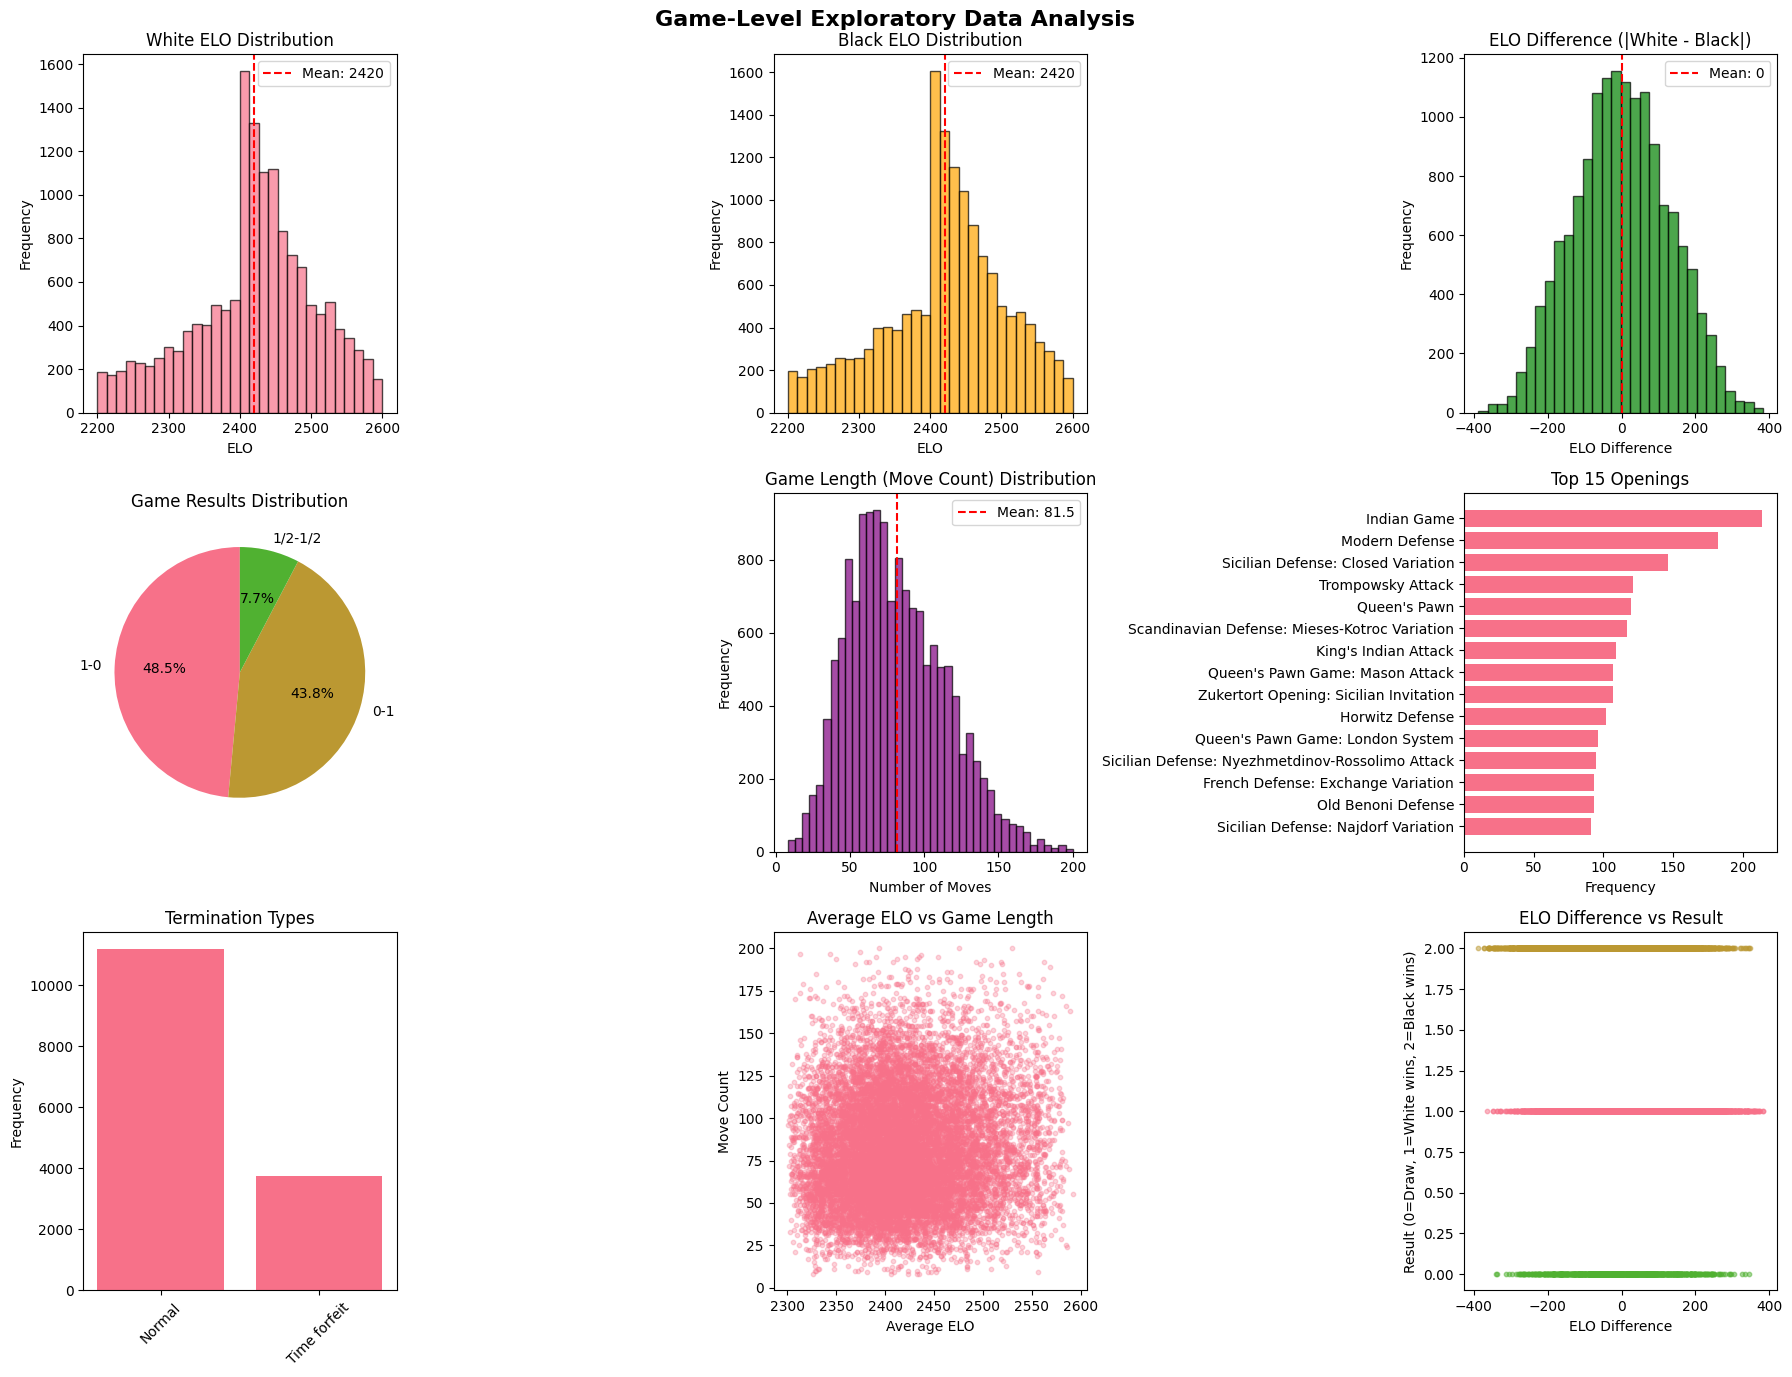

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Game-Level Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. White ELO distribution
axes[0, 0].hist(df_games['white_elo'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('White ELO Distribution')
axes[0, 0].set_xlabel('ELO')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_games['white_elo'].mean(), color='red', linestyle='--', label=f"Mean: {df_games['white_elo'].mean():.0f}")
axes[0, 0].legend()

# 2. Black ELO distribution
axes[0, 1].hist(df_games['black_elo'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Black ELO Distribution')
axes[0, 1].set_xlabel('ELO')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_games['black_elo'].mean(), color='red', linestyle='--', label=f"Mean: {df_games['black_elo'].mean():.0f}")
axes[0, 1].legend()

# 3. ELO difference distribution
axes[0, 2].hist(df_games['elo_diff'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('ELO Difference (|White - Black|)')
axes[0, 2].set_xlabel('ELO Difference')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(df_games['elo_diff'].mean(), color='red', linestyle='--', label=f"Mean: {df_games['elo_diff'].mean():.0f}")
axes[0, 2].legend()

# 4. Results distribution (pie chart)
result_counts = df_games['result'].value_counts()
axes[1, 0].pie(result_counts.values, labels=result_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Game Results Distribution')

# 5. Move count distribution
axes[1, 1].hist(df_games['move_count'], bins=40, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('Game Length (Move Count) Distribution')
axes[1, 1].set_xlabel('Number of Moves')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(df_games['move_count'].mean(), color='red', linestyle='--', label=f"Mean: {df_games['move_count'].mean():.1f}")
axes[1, 1].legend()

# 6. Top 15 openings
top_openings = df_games['opening'].value_counts().head(15)
axes[1, 2].barh(range(len(top_openings)), top_openings.values)
axes[1, 2].set_yticks(range(len(top_openings)))
axes[1, 2].set_yticklabels(top_openings.index)
axes[1, 2].set_title('Top 15 Openings')
axes[1, 2].set_xlabel('Frequency')
axes[1, 2].invert_yaxis()

# 7. Termination types
term_counts = df_games['termination'].value_counts()
axes[2, 0].bar(range(len(term_counts)), term_counts.values, tick_label=term_counts.index)
axes[2, 0].set_title('Termination Types')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].tick_params(axis='x', rotation=45)

# 8. Average ELO vs Game Length
axes[2, 1].scatter(df_games['avg_elo'], df_games['move_count'], alpha=0.3, s=10)
axes[2, 1].set_title('Average ELO vs Game Length')
axes[2, 1].set_xlabel('Average ELO')
axes[2, 1].set_ylabel('Move Count')

# 9. ELO difference vs Result
result_mapping = {'1-0': 1, '0-1': 2, '1/2-1/2': 0}
df_games['result_numeric'] = df_games['result'].map(result_mapping)
for result in df_games['result'].unique():
    subset = df_games[df_games['result'] == result]
    axes[2, 2].scatter(subset['elo_diff'], subset['result_numeric'], label=result, alpha=0.5, s=10)
axes[2, 2].set_title('ELO Difference vs Result')
axes[2, 2].set_xlabel('ELO Difference')
axes[2, 2].set_ylabel('Result (0=Draw, 1=White wins, 2=Black wins)')
# axes[2, 2].legend()

plt.tight_layout()
plt.show()

---
# 3. Position Extraction

Traverse every game and record each board state: FEN, played move, all legal moves, ELO, side-to-move, and game result.


## 3.1 Extract Positions from Games

In [8]:
max_move_number = None

positions_data = []

for game_id, game in enumerate(tqdm(games, desc="Extracting positions")):

    move_count = sum(1 for _ in game.mainline_moves())
    if move_count < 8 or move_count > 200:
        continue
    
    # Get game metadata
    try:
        white_elo = int(game.headers.get("WhiteElo", 0))
        black_elo = int(game.headers.get("BlackElo", 0))
    except:
        white_elo = 0
        black_elo = 0
    
    result = game.headers.get("Result", "*")
    eco = game.headers.get("ECO", "Unknown")
    
    # Traverse the game
    board = game.board()
    move_number = 0
    
    for move in game.mainline_moves():
        move_number += 1
        
        # Skip if max_move_number is set and we've exceeded it
        if max_move_number is not None and move_number > max_move_number:
            break
        
        # Get current position info
        fen = board.fen()
        legal_moves = [m.uci() for m in board.legal_moves]
        played_move = move.uci()
        side_to_move = 'white' if board.turn else 'black'
        
        # Store position data
        positions_data.append({
            'game_id': game_id,
            'move_number': move_number,
            'fen': fen,
            # 'board': board.copy(),  # Store copy of board
            'played_move': played_move,
            # 'legal_moves': legal_moves,
            'num_legal_moves': len(legal_moves),
            'white_elo': white_elo,
            'black_elo': black_elo,
            'side_to_move': side_to_move,
            'result': result,
            'eco': eco
        })
        
        # Make the move on the board
        board.push(move)

print(f"\n{'='*80}")
print(f"Total positions extracted: {len(positions_data):,}")
print(f"Average positions per game: {len(positions_data) / len(games):.1f}")
print(f"{'='*80}")

Extracting positions: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [00:52<00:00, 285.44it/s]


Total positions extracted: 1,218,514
Average positions per game: 81.2


## 3.2 Build Positions DataFrame

In [9]:
# Create DataFrame (without board objects for easier viewing)
df_positions = pd.DataFrame([{
    'game_id': p['game_id'],
    'move_number': p['move_number'],
    'fen': p['fen'],
    'played_move': p['played_move'],
    'num_legal_moves': p['num_legal_moves'],
    'white_elo': p['white_elo'],
    'black_elo': p['black_elo'],
    'side_to_move': p['side_to_move'],
    'result': p['result'],
    'eco': p['eco']
} for p in positions_data])

print("Positions DataFrame created!")
print(f"Shape: {df_positions.shape}")
print("\nFirst few rows:")
df_positions.head(10)

Positions DataFrame created!
Shape: (1218514, 10)

First few rows:


,game_id,move_number,fen,played_move,num_legal_moves,white_elo,black_elo,side_to_move,result,eco
0,0,1,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,d2d4,20,2482,2473,white,1-0,A43
1,0,2,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,c7c5,20,2482,2473,black,1-0,A43
2,0,3,rnbqkbnr/pp1ppppp/8/2p5/3P4/8/PPP1PPPP/RNBQKBN...,g1f3,29,2482,2473,white,1-0,A43
3,0,4,rnbqkbnr/pp1ppppp/8/2p5/3P4/5N2/PPP1PPPP/RNBQK...,c5d4,23,2482,2473,black,1-0,A43
4,0,5,rnbqkbnr/pp1ppppp/8/8/3p4/5N2/PPP1PPPP/RNBQKB1...,f3d4,31,2482,2473,white,1-0,A43
5,0,6,rnbqkbnr/pp1ppppp/8/8/3N4/8/PPP1PPPP/RNBQKB1R ...,d7d5,21,2482,2473,black,1-0,A43
6,0,7,rnbqkbnr/pp2pppp/8/3p4/3N4/8/PPP1PPPP/RNBQKB1R...,g2g3,32,2482,2473,white,1-0,A43
7,0,8,rnbqkbnr/pp2pppp/8/3p4/3N4/6P1/PPP1PP1P/RNBQKB...,e7e5,28,2482,2473,black,1-0,A43
8,0,9,rnbqkbnr/pp3ppp/8/3pp3/3N4/6P1/PPP1PP1P/RNBQKB...,d4b3,33,2482,2473,white,1-0,A43
9,0,10,rnbqkbnr/pp3ppp/8/3pp3/8/1N4P1/PPP1PP1P/RNBQKB...,b8c6,39,2482,2473,black,1-0,A43


---
# 4. Move-Level Exploratory Data Analysis

## 4.1 Move Statistics

In [10]:
print("Move-Level Statistics:")
print("=" * 80)

# Basic stats
print(f"\nTotal positions: {len(df_positions):,}")
print(f"Unique games: {df_positions['game_id'].nunique():,}")

# Legal moves statistics
print(f"\nLegal Moves per Position:")
print(df_positions['num_legal_moves'].describe())

# All played moves
all_played_moves = df_positions['played_move'].values
unique_moves = df_positions['played_move'].nunique()

print(f"\nUnique moves played across all positions: {unique_moves:,}")

# Most common moves
print(f"\nTop 30 Most Frequently Played Moves:")
move_freq = df_positions['played_move'].value_counts().head(30)
for i, (move, count) in enumerate(move_freq.items(), 1):
    pct = count / len(df_positions) * 100
    print(f"{i:2d}. {move:6s} - {count:6,} times ({pct:5.2f}%)")

# Side to move distribution
print(f"\nSide to Move Distribution:")
print(df_positions['side_to_move'].value_counts())

# Move number distribution
print(f"\nMove Number Statistics:")
print(df_positions['move_number'].describe())

Move-Level Statistics:

Total positions: 1,218,514
Unique games: 14,945

Legal Moves per Position:
count    1.218514e+06
mean     2.953270e+01
std      1.175342e+01
min      1.000000e+00
25%      2.200000e+01
50%      3.100000e+01
75%      3.800000e+01
max      7.900000e+01
Name: num_legal_moves, dtype: float64

Unique moves played across all positions: 1,871

Top 30 Most Frequently Played Moves:
 1. g1f3   - 13,028 times ( 1.07%)
 2. g8f6   - 12,997 times ( 1.07%)
 3. d2d4   - 12,515 times ( 1.03%)
 4. e8g8   - 11,688 times ( 0.96%)
 5. e1g1   - 11,482 times ( 0.94%)
 6. b1c3   - 11,060 times ( 0.91%)
 7. e2e4   - 10,706 times ( 0.88%)
 8. e7e6   -  9,457 times ( 0.78%)
 9. b8c6   -  9,219 times ( 0.76%)
10. g7g6   -  8,611 times ( 0.71%)
11. d7d5   -  8,328 times ( 0.68%)
12. c7c5   -  8,211 times ( 0.67%)
13. c2c4   -  7,861 times ( 0.65%)
14. d7d6   -  7,166 times ( 0.59%)
15. g2g3   -  6,991 times ( 0.57%)
16. h2h3   -  6,502 times ( 0.53%)
17. a7a6   -  6,414 times ( 0.53%)
18. h

## 4.2 Move Frequency & Coverage Analysis

In [11]:
# Analyze class imbalance
move_counts = df_positions['played_move'].value_counts()

print("Move Frequency Distribution Analysis:")
print("=" * 80)

# How many moves appear only once, twice, etc.
freq_distribution = Counter(move_counts.values)
print("\nMove Frequency Distribution:")
for freq in sorted(freq_distribution.keys())[:20]:  # First 20
    count = freq_distribution[freq]
    print(f"Moves appearing {freq:3d} time(s): {count:4d} moves")

# Coverage analysis
print("\n" + "=" * 80)
print("Coverage Analysis (Top-N moves cover X% of all positions):")
print("=" * 80)

total_positions = len(df_positions)
cumsum = move_counts.cumsum()

for n in [10, 20, 50, 100, 200, 500, 1000]:
    if n <= len(cumsum):
        coverage = cumsum.iloc[n-1] / total_positions * 100
        print(f"Top {n:4d} moves cover: {coverage:6.2f}% of positions")

# Rare moves
rare_moves = (move_counts <= 5).sum()
very_rare_moves = (move_counts == 1).sum()

print(f"\nRare moves (≤5 occurrences): {rare_moves:,} ({rare_moves/len(move_counts)*100:.2f}%)")
print(f"Very rare moves (1 occurrence): {very_rare_moves:,} ({very_rare_moves/len(move_counts)*100:.2f}%)")

Move Frequency Distribution Analysis:

Move Frequency Distribution:
Moves appearing   1 time(s):   28 moves
Moves appearing   2 time(s):   10 moves
Moves appearing   3 time(s):    5 moves
Moves appearing   4 time(s):    4 moves
Moves appearing   5 time(s):    3 moves
Moves appearing   6 time(s):    5 moves
Moves appearing   7 time(s):    4 moves
Moves appearing   8 time(s):    3 moves
Moves appearing   9 time(s):    4 moves
Moves appearing  10 time(s):    2 moves
Moves appearing  11 time(s):    4 moves
Moves appearing  12 time(s):    1 moves
Moves appearing  13 time(s):    1 moves
Moves appearing  14 time(s):    1 moves
Moves appearing  15 time(s):    1 moves
Moves appearing  18 time(s):    1 moves
Moves appearing  19 time(s):    1 moves
Moves appearing  20 time(s):    3 moves
Moves appearing  22 time(s):    2 moves
Moves appearing  25 time(s):    3 moves

Coverage Analysis (Top-N moves cover X% of all positions):
Top   10 moves cover:   9.09% of positions
Top   20 moves cover:  14.80%

## 4.3 Visualizations

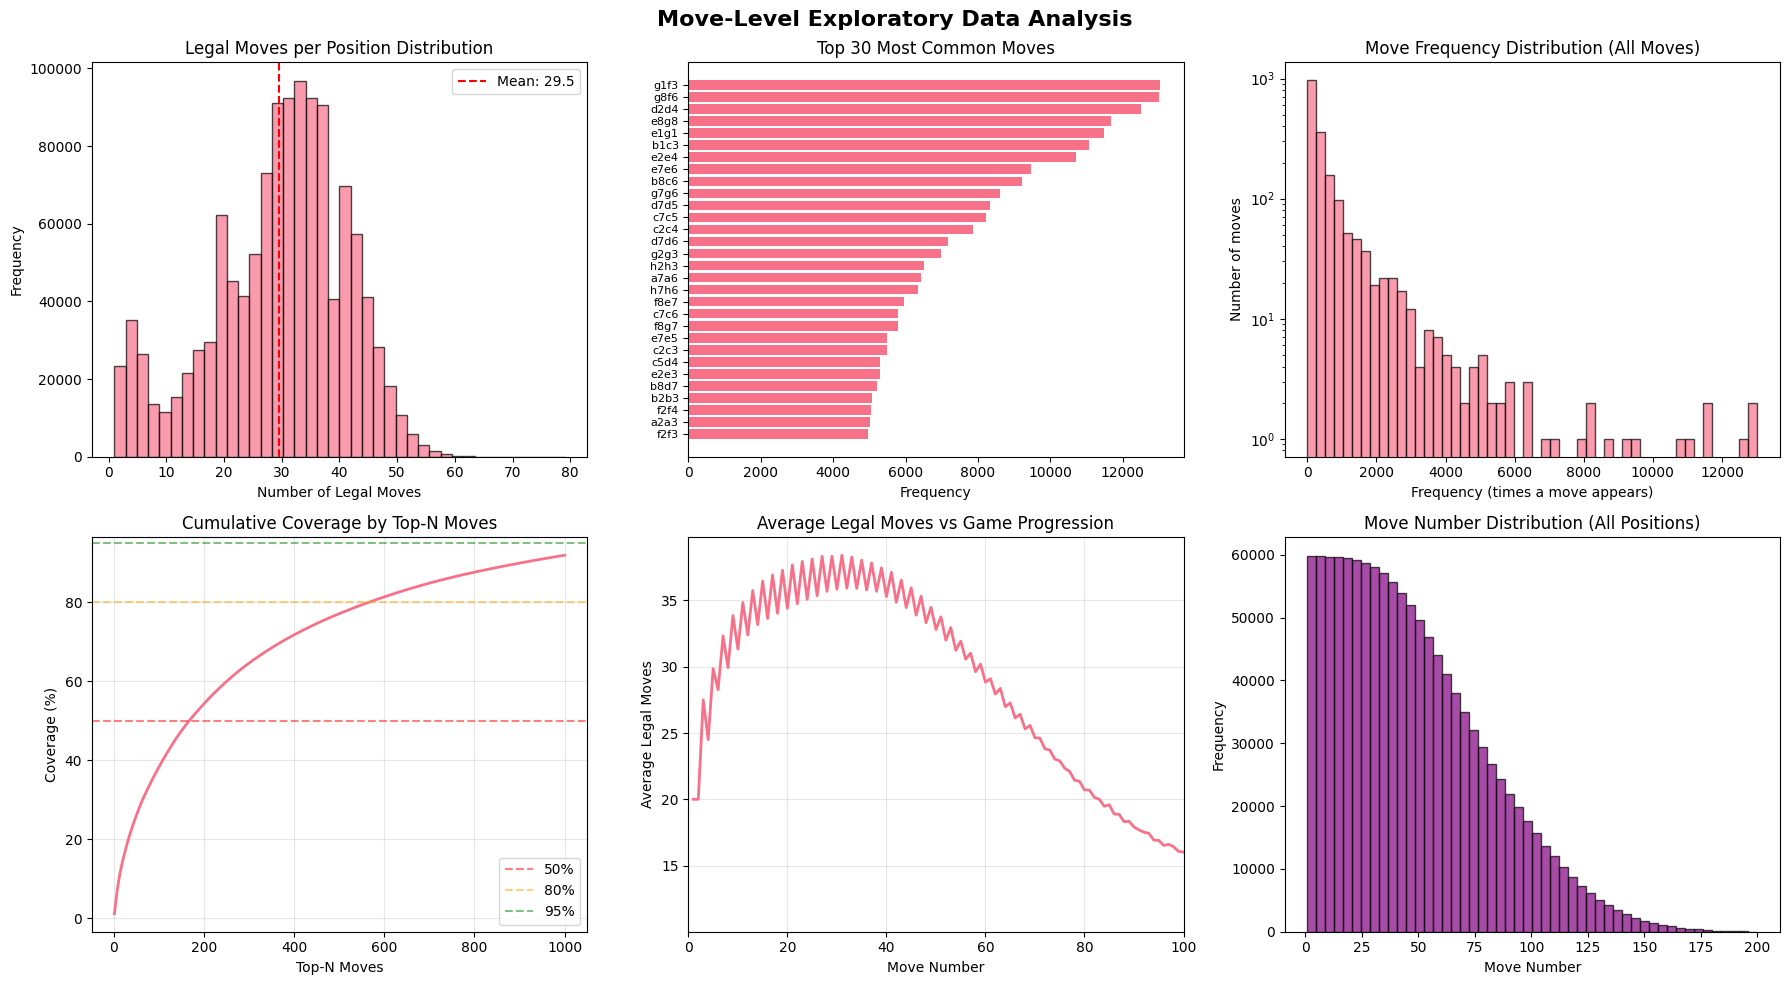

In [12]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Move-Level Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Legal moves per position distribution
axes[0, 0].hist(df_positions['num_legal_moves'], bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Legal Moves per Position Distribution')
axes[0, 0].set_xlabel('Number of Legal Moves')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_positions['num_legal_moves'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {df_positions['num_legal_moves'].mean():.1f}")
axes[0, 0].legend()

# 2. Top 30 most common moves
top_moves = df_positions['played_move'].value_counts().head(30)
axes[0, 1].barh(range(len(top_moves)), top_moves.values)
axes[0, 1].set_yticks(range(len(top_moves)))
axes[0, 1].set_yticklabels(top_moves.index, fontsize=8)
axes[0, 1].set_title('Top 30 Most Common Moves')
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].invert_yaxis()

# 3. Move frequency distribution (log scale)
move_counts = df_positions['played_move'].value_counts()
axes[0, 2].hist(move_counts.values, bins=50, edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Move Frequency Distribution (All Moves)')
axes[0, 2].set_xlabel('Frequency (times a move appears)')
axes[0, 2].set_ylabel('Number of moves')
axes[0, 2].set_yscale('log')

# 4. Cumulative coverage plot
cumsum_pct = move_counts.cumsum() / len(df_positions) * 100
axes[1, 0].plot(range(1, min(1001, len(cumsum_pct)+1)), cumsum_pct.iloc[:1000].values, linewidth=2)
axes[1, 0].set_title('Cumulative Coverage by Top-N Moves')
axes[1, 0].set_xlabel('Top-N Moves')
axes[1, 0].set_ylabel('Coverage (%)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1, 0].axhline(80, color='orange', linestyle='--', alpha=0.5, label='80%')
axes[1, 0].axhline(95, color='green', linestyle='--', alpha=0.5, label='95%')
axes[1, 0].legend()

# 5. Legal moves vs move number
avg_legal_by_move = df_positions.groupby('move_number')['num_legal_moves'].mean()
axes[1, 1].plot(avg_legal_by_move.index, avg_legal_by_move.values, linewidth=2)
axes[1, 1].set_title('Average Legal Moves vs Game Progression')
axes[1, 1].set_xlabel('Move Number')
axes[1, 1].set_ylabel('Average Legal Moves')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, min(100, df_positions['move_number'].max()))

# 6. Move number distribution
axes[1, 2].hist(df_positions['move_number'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 2].set_title('Move Number Distribution (All Positions)')
axes[1, 2].set_xlabel('Move Number')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
# 5. Position Features Analysis

## 5.1 Extract Position Features

Compute material counts, castling rights, en-passant, and a game-phase heuristic for every position.


In [13]:
positions_data_sample = positions_data
features_list = []

# Piece values for material calculation
PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0
}

for pos_data in tqdm(positions_data_sample, desc="Extracting position features"):
    board = chess.Board(pos_data['fen'])
    
    # Material count
    white_material = sum(PIECE_VALUES[piece.piece_type] for piece in board.piece_map().values() if piece.color == chess.WHITE)
    black_material = sum(PIECE_VALUES[piece.piece_type] for piece in board.piece_map().values() if piece.color == chess.BLACK)
    
    # Piece counts
    white_pieces = sum(1 for piece in board.piece_map().values() if piece.color == chess.WHITE)
    black_pieces = sum(1 for piece in board.piece_map().values() if piece.color == chess.BLACK)
    
    # Castling rights
    can_castle_kingside_white = board.has_kingside_castling_rights(chess.WHITE)
    can_castle_queenside_white = board.has_queenside_castling_rights(chess.WHITE)
    can_castle_kingside_black = board.has_kingside_castling_rights(chess.BLACK)
    can_castle_queenside_black = board.has_queenside_castling_rights(chess.BLACK)
    
    # En passant
    has_en_passant = board.ep_square is not None
    
    # Game phase heuristic
    total_material = white_material + black_material
    if total_material >= 60:  # Close to starting material (78)
        game_phase = 'opening'
    elif total_material >= 30:
        game_phase = 'middlegame'
    else:
        game_phase = 'endgame'
    
    features_list.append({
        'game_id': pos_data['game_id'],
        'move_number': pos_data['move_number'],
        'white_material': white_material,
        'black_material': black_material,
        'material_balance': white_material - black_material,
        'total_material': total_material,
        'white_pieces': white_pieces,
        'black_pieces': black_pieces,
        'total_pieces': white_pieces + black_pieces,
        'castle_K': can_castle_kingside_white,
        'castle_Q': can_castle_queenside_white,
        'castle_k': can_castle_kingside_black,
        'castle_q': can_castle_queenside_black,
        'has_en_passant': has_en_passant,
        'game_phase': game_phase,
        'halfmove_clock': board.halfmove_clock,
        'fullmove_number': board.fullmove_number
    })

df_features = pd.DataFrame(features_list)

print(f"\nFeatures DataFrame shape: {df_features.shape}")
print("\nFirst few rows:")
df_features.head()

Extracting position features: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1218514/1218514 [01:10<00:00, 17371.51it/s]



Features DataFrame shape: (1218514, 17)

First few rows:


,game_id,move_number,white_material,black_material,material_balance,total_material,white_pieces,black_pieces,total_pieces,castle_K,castle_Q,castle_k,castle_q,has_en_passant,game_phase,halfmove_clock,fullmove_number
0,0,1,39,39,0,78,16,16,32,True,True,True,True,False,opening,0,1
1,0,2,39,39,0,78,16,16,32,True,True,True,True,False,opening,0,1
2,0,3,39,39,0,78,16,16,32,True,True,True,True,False,opening,0,2
3,0,4,39,39,0,78,16,16,32,True,True,True,True,False,opening,1,2
4,0,5,38,39,-1,77,15,16,31,True,True,True,True,False,opening,0,3


## 5.2 Feature Statistics

In [14]:
print("Position Feature Statistics:")
print("=" * 80)

# Numerical features
print("\nNumerical Features Summary:")
numerical_cols = ['white_material', 'black_material', 'material_balance', 'total_material',
                  'white_pieces', 'black_pieces', 'total_pieces', 'halfmove_clock']
print(df_features[numerical_cols].describe())

print("\n",df_features.info())


# Castling rights
print("\nCastling Rights Distribution:")
print(f"White can castle kingside:  {df_features['castle_K'].sum():6d} ({df_features['castle_K'].mean()*100:5.2f}%)")
print(f"White can castle queenside: {df_features['castle_Q'].sum():6d} ({df_features['castle_Q'].mean()*100:5.2f}%)")
print(f"Black can castle kingside:  {df_features['castle_k'].sum():6d} ({df_features['castle_k'].mean()*100:5.2f}%)")
print(f"Black can castle queenside: {df_features['castle_q'].sum():6d} ({df_features['castle_q'].mean()*100:5.2f}%)")

# En passant
print(f"\nEn passant available: {df_features['has_en_passant'].sum():6d} ({df_features['has_en_passant'].mean()*100:5.2f}%)")

# Game phase
print("\nGame Phase Distribution:")
print(df_features['game_phase'].value_counts())
print("\nPercentages:")
print(df_features['game_phase'].value_counts(normalize=True) * 100)

Position Feature Statistics:

Numerical Features Summary:
       white_material  black_material  material_balance  total_material  \
count    1.218514e+06    1.218514e+06      1.218514e+06    1.218514e+06   
mean     2.611028e+01    2.613384e+01     -2.355984e-02    5.224412e+01   
std      1.175871e+01    1.175443e+01      2.484159e+00    2.338154e+01   
min      0.000000e+00    0.000000e+00     -4.500000e+01    1.000000e+00   
25%      1.600000e+01    1.600000e+01      0.000000e+00    3.100000e+01   
50%      2.900000e+01    2.900000e+01      0.000000e+00    5.900000e+01   
75%      3.800000e+01    3.800000e+01      0.000000e+00    7.500000e+01   
max      4.600000e+01    4.500000e+01      3.100000e+01    8.100000e+01   

       white_pieces  black_pieces  total_pieces  halfmove_clock  
count  1.218514e+06  1.218514e+06  1.218514e+06    1.218514e+06  
mean   1.115755e+01  1.118051e+01  2.233806e+01    1.870092e+00  
std    4.057582e+00  4.053501e+00  8.041667e+00    3.421499e+00  
mi

## 5.3 Visualizations

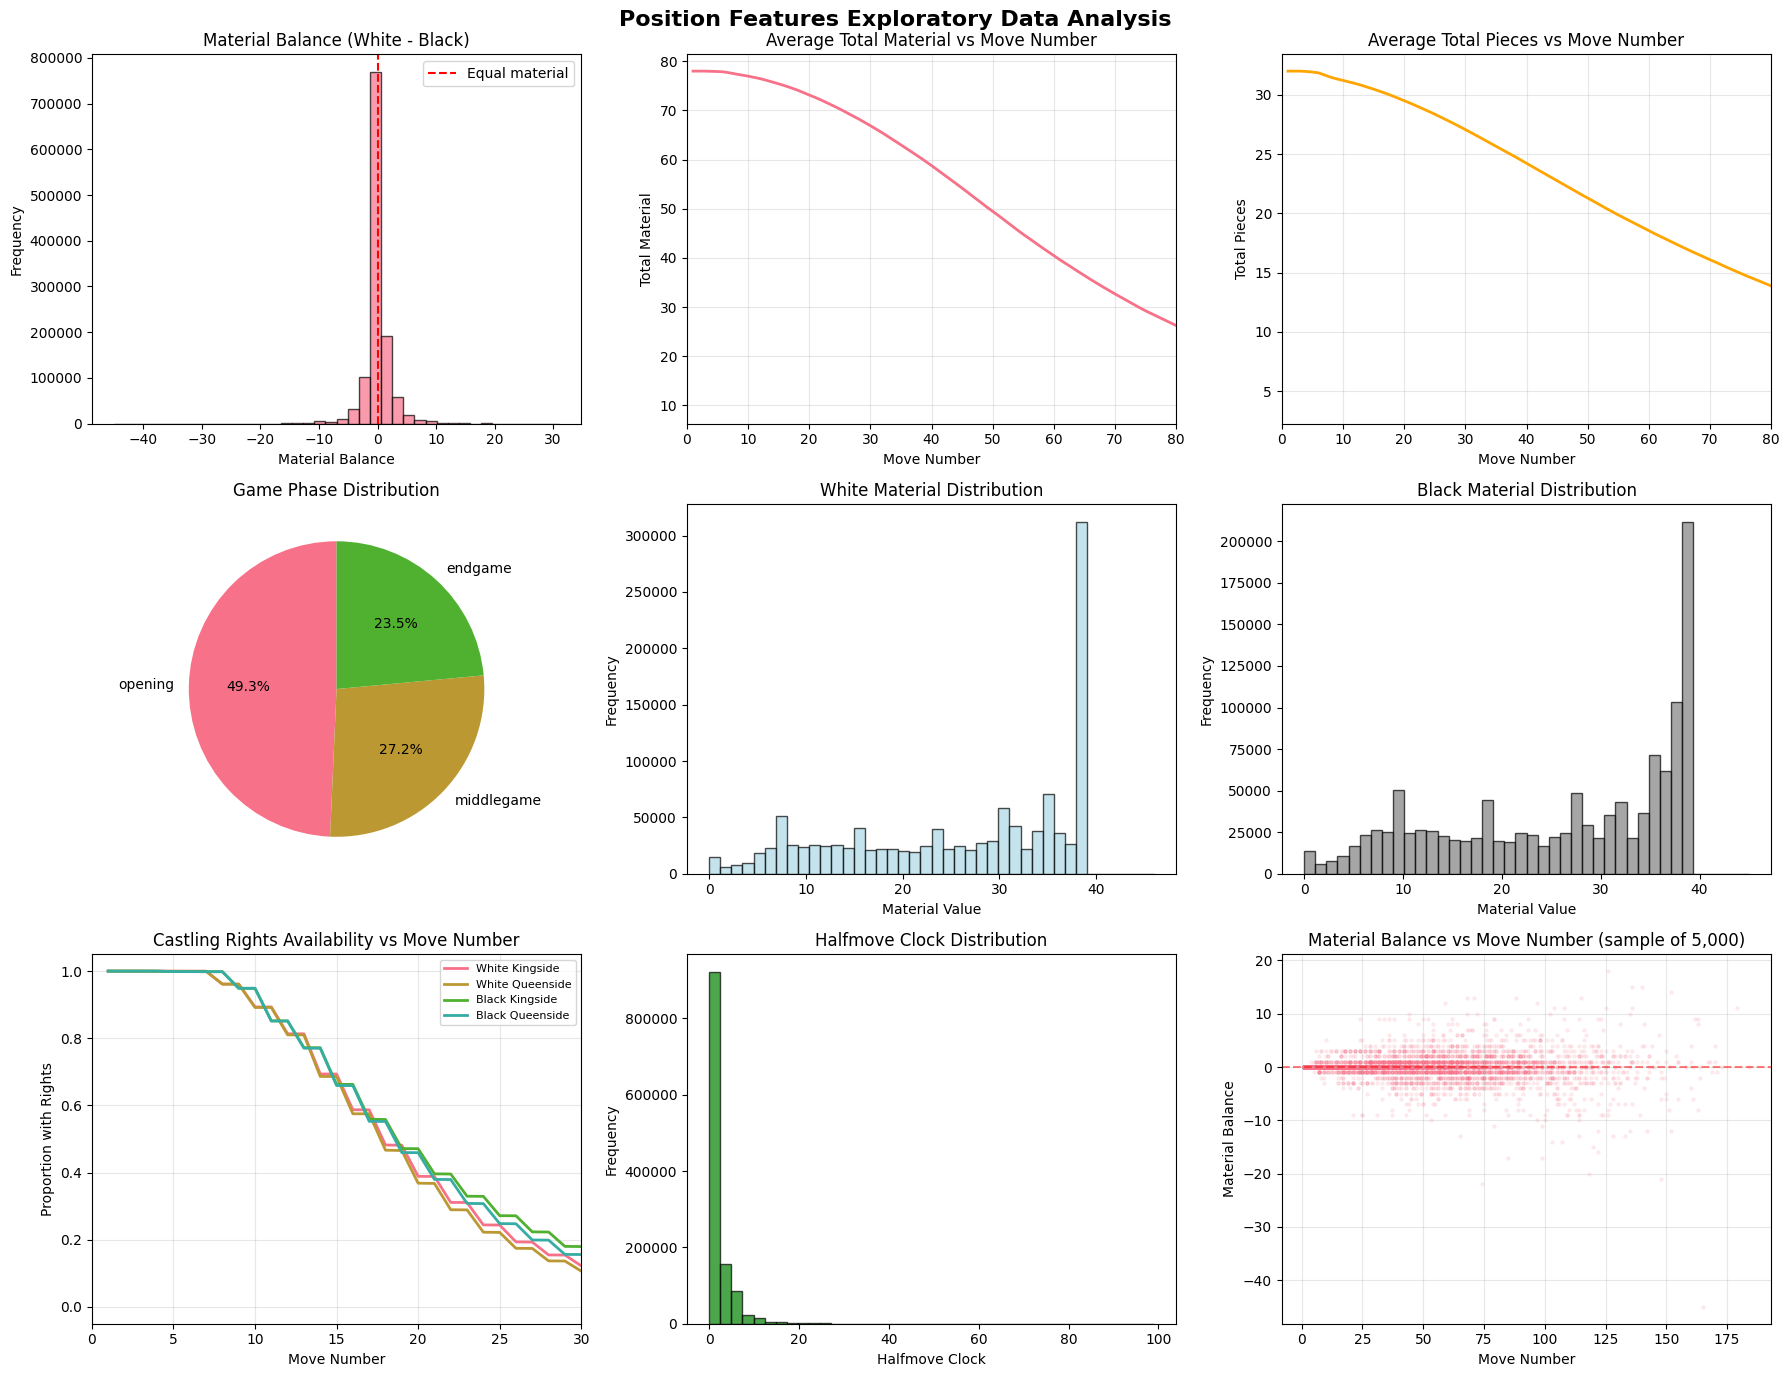

In [15]:
# Create visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Position Features Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Material balance distribution
axes[0, 0].hist(df_features['material_balance'], bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Material Balance (White - Black)')
axes[0, 0].set_xlabel('Material Balance')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(0, color='red', linestyle='--', label='Equal material')
axes[0, 0].legend()

# 2. Total material over game progression
material_by_move = df_features.groupby('move_number')['total_material'].mean()
axes[0, 1].plot(material_by_move.index, material_by_move.values, linewidth=2)
axes[0, 1].set_title('Average Total Material vs Move Number')
axes[0, 1].set_xlabel('Move Number')
axes[0, 1].set_ylabel('Total Material')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, min(80, df_features['move_number'].max()))

# 3. Total pieces over game progression
pieces_by_move = df_features.groupby('move_number')['total_pieces'].mean()
axes[0, 2].plot(pieces_by_move.index, pieces_by_move.values, linewidth=2, color='orange')
axes[0, 2].set_title('Average Total Pieces vs Move Number')
axes[0, 2].set_xlabel('Move Number')
axes[0, 2].set_ylabel('Total Pieces')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xlim(0, min(80, df_features['move_number'].max()))

# 4. Game phase distribution
phase_counts = df_features['game_phase'].value_counts()
axes[1, 0].pie(phase_counts.values, labels=phase_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Game Phase Distribution')

# 5. White material distribution
axes[1, 1].hist(df_features['white_material'], bins=40, edgecolor='black', alpha=0.7, color='lightblue')
axes[1, 1].set_title('White Material Distribution')
axes[1, 1].set_xlabel('Material Value')
axes[1, 1].set_ylabel('Frequency')

# 6. Black material distribution
axes[1, 2].hist(df_features['black_material'], bins=40, edgecolor='black', alpha=0.7, color='gray')
axes[1, 2].set_title('Black Material Distribution')
axes[1, 2].set_xlabel('Material Value')
axes[1, 2].set_ylabel('Frequency')

# 7. Castling rights over game progression
castle_by_move = df_features.groupby('move_number')[['castle_K', 'castle_Q', 'castle_k', 'castle_q']].mean()
axes[2, 0].plot(castle_by_move.index, castle_by_move['castle_K'], label='White Kingside', linewidth=2)
axes[2, 0].plot(castle_by_move.index, castle_by_move['castle_Q'], label='White Queenside', linewidth=2)
axes[2, 0].plot(castle_by_move.index, castle_by_move['castle_k'], label='Black Kingside', linewidth=2)
axes[2, 0].plot(castle_by_move.index, castle_by_move['castle_q'], label='Black Queenside', linewidth=2)
axes[2, 0].set_title('Castling Rights Availability vs Move Number')
axes[2, 0].set_xlabel('Move Number')
axes[2, 0].set_ylabel('Proportion with Rights')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(0, min(30, df_features['move_number'].max()))

# 8. Halfmove clock distribution
axes[2, 1].hist(df_features['halfmove_clock'], bins=40, edgecolor='black', alpha=0.7, color='green')
axes[2, 1].set_title('Halfmove Clock Distribution')
axes[2, 1].set_xlabel('Halfmove Clock')
axes[2, 1].set_ylabel('Frequency')

# 9. Material balance vs move number (scatter sample)
sample_size = min(5000, len(df_features))
sample_df = df_features.sample(n=sample_size, random_state=42)
axes[2, 2].scatter(sample_df['move_number'], sample_df['material_balance'], alpha=0.1, s=5)
axes[2, 2].set_title(f'Material Balance vs Move Number (sample of {sample_size:,})')
axes[2, 2].set_xlabel('Move Number')
axes[2, 2].set_ylabel('Material Balance')
axes[2, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 6. Feature Engineering

Three encoding functions produce the full 802-dim feature vector used by every model:

| Function | Dims | Description |
|---|---|---|
| `board_to_array(board)` | 768 | One-hot: 64 squares × 12 piece types |
| `move_to_semantic_array(board, move)` | 24 | Piece type OHE, color, coordinates, distances, capture, special flags |
| `get_metadata_features_fast(board)` | 10 | Castling rights, side-to-move, en-passant, mobility, material |

> **Why semantic move features?** The old encoding used 128 one-hot from/to-square columns, treating `from_square=4` as if it has a magnitude relationship. The 24-column encoding avoids fake ordinal math by one-hot encoding piece types and using raw rank/file coordinates only where arithmetic is valid.


## 6.1 `board_to_array` — 768-dim Board Representation

In [16]:
import random

def board_to_array(board):
    arr = [0] * 768

    for piece_type in chess.PIECE_TYPES:
        # white
        for square in board.pieces(piece_type, chess.WHITE):
            idx = piece_type - 1
            arr[square * 12 + idx] = 1

        # black
        for square in board.pieces(piece_type, chess.BLACK):
            idx = piece_type - 1 + 6
            arr[square * 12 + idx] = 1

    return arr


## 6.2 `move_to_semantic_array` & `get_column_names_v2` — Move Features

```
Moving piece type OHE (6) + color OHE (2)
+ from rank/file (2)  + to rank/file (2)
+ rank/file distance (2)
+ is_capture (1) + captured piece type OHE (6)
+ gives_check (1) + is_promotion (1) + is_castling (1)
= 24 total
```


In [17]:
def move_to_semantic_array(board, move):
    """
    Convert a move into 24 semantic features.
    Total: 6 + 2 + 2 + 2 + 2 + 1 + 6 + 1 + 1 + 1 = 24 columns
    """
    arr = []
    piece = board.piece_at(move.from_square)

    piece_type_onehot = [0] * 6
    if piece is not None:
        piece_type_onehot[piece.piece_type - 1] = 1
    arr.extend(piece_type_onehot)

    if piece is not None:
        arr.append(1 if piece.color == chess.WHITE else 0)
        arr.append(1 if piece.color == chess.BLACK else 0)
    else:
        arr.extend([0, 0])

    from_rank = move.from_square // 8
    from_file = move.from_square % 8
    arr.append(from_rank)
    arr.append(from_file)

    to_rank = move.to_square // 8
    to_file = move.to_square % 8
    arr.append(to_rank)
    arr.append(to_file)

    arr.append(abs(to_rank - from_rank))
    arr.append(abs(to_file - from_file))

    captured_piece = board.piece_at(move.to_square)
    is_capture = 1 if captured_piece is not None else 0
    arr.append(is_capture)

    captured_type_onehot = [0] * 6
    if captured_piece is not None:
        captured_type_onehot[captured_piece.piece_type - 1] = 1
    arr.extend(captured_type_onehot)

    board_copy = board.copy()
    board_copy.push(move)
    arr.append(1 if board_copy.is_check() else 0)
    arr.append(1 if move.promotion is not None else 0)
    arr.append(1 if board.is_castling(move) else 0)

    return arr  # 24 values


## 6.3 `get_metadata_features_fast` — 10-dim Position Metadata

In [18]:
PIECE_VALUES = {
    chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3,
    chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 0
}

def get_metadata_features_fast(board):
    """Fast metadata — no ELO needed (used during inference)."""
    piece_map = board.piece_map().values()
    wm = sum(PIECE_VALUES[p.piece_type] for p in piece_map if p.color == chess.WHITE)
    bm = sum(PIECE_VALUES[p.piece_type] for p in piece_map if p.color == chess.BLACK)

    return [
        int(board.has_kingside_castling_rights(chess.WHITE)),
        int(board.has_queenside_castling_rights(chess.WHITE)),
        int(board.has_kingside_castling_rights(chess.BLACK)),
        int(board.has_queenside_castling_rights(chess.BLACK)),
        int(board.turn == chess.BLACK),
        int(board.ep_square is not None),
        board.legal_moves.count(),
        wm, bm, wm - bm
    ]


## 6.4 `get_column_names_v2` — Full Feature Column Names

In [19]:
def get_column_names_v2():
    cols = []

    # ── Board features (768) ───────────────────────────────
    for square in chess.SQUARES:
        for i in range(12):
            cols.append(f"square_{square}_piece_{i}")

    # ── Semantic move features (24) ────────────────────────
    piece_names = ["pawn", "knight", "bishop", "rook", "queen", "king"]

    for p in piece_names:
        cols.append(f"moving_{p}")

    cols.append("moving_is_white")
    cols.append("moving_is_black")

    cols.extend(["from_rank", "from_file", "to_rank", "to_file"])
    cols.extend(["rank_distance", "file_distance"])
    cols.append("is_capture")

    for p in piece_names:
        cols.append(f"captured_{p}")

    cols.extend(["gives_check", "is_promotion", "is_castling"])

    # ── Metadata features (10) ────────────────────────────
    cols.extend([
        "w_k_castle", "w_q_castle",
        "b_k_castle", "b_q_castle",
        "black_to_move",
        "en_passant",
        "mobility",
        "white_material",
        "black_material",
        "material_diff"
    ])

    cols.append("label")
    return cols


---
# 7. Feature Analysis

Audit the feature space **before training** to identify dead columns (all-zero or constant) that can be dropped from the pipeline.

We build a small probe dataset here just for the audit. The full datasets are built in Section 8 using only `live_feature_cols`.


## 7.1 Dataset Builder Functions

In [20]:
def create_dataset_v2_fast(games, max_positions=300000, num_negatives=3,
                          seed=42, min_move_number=10, opening_games=1000):

    random.seed(seed)

    rows = []
    meta = []

    append = rows.append
    append_meta = meta.append

    pos_id = 0
    count = 0

    for game_idx, game in enumerate(tqdm(games)):
        board = game.board()
        move_number = 0

        skip_openings = (game_idx >= opening_games)

        for move in game.mainline_moves():
            move_number += 1

            if skip_openings and move_number < min_move_number:
                board.push(move)
                continue

            if count >= max_positions:
                break

            # ── compute once ─────────────────────
            board_arr = board_to_array(board)
            meta_features = get_metadata_features_fast(board)

            legal_moves = list(board.legal_moves)

            # cache move features
            move_cache = {
                m: move_to_semantic_array(board, m)
                for m in legal_moves
            }

            # ✅ positive
            row = board_arr.copy()
            row.extend(move_cache[move])
            row.extend(meta_features)
            row.append(1)

            append(row)
            append_meta((pos_id, game_idx))

            # ❌ negatives
            negatives = legal_moves.copy()
            negatives.remove(move)

            k = min(num_negatives, len(negatives))
            if k > 0:
                sampled = random.sample(negatives, k)

                for neg in sampled:
                    row = board_arr.copy()
                    row.extend(move_cache[neg])
                    row.extend(meta_features)
                    row.append(0)

                    append(row)
                    append_meta((pos_id, game_idx))

            board.push(move)
            pos_id += 1
            count += 1

        if count >= max_positions:
            break

    arr = np.array(rows, dtype=np.int16)
    df = pd.DataFrame(arr, columns=get_column_names_v2())

    meta_arr = np.array(meta, dtype=np.int32)
    df["position_id"] = meta_arr[:, 0]
    df["game_id"] = meta_arr[:, 1]

    return df

In [21]:
import random
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm


# ─────────────────────────────────────────────
# Worker function (must be top-level)
# ─────────────────────────────────────────────
def process_game(game_idx, game, num_negatives, min_move_number, opening_games):
    rows = []
    meta = []

    board = game.board()
    move_number = 0
    pos_id_local = 0

    skip_openings = (game_idx >= opening_games)

    for move in game.mainline_moves():
        move_number += 1

        if skip_openings and move_number < min_move_number:
            board.push(move)
            continue

        # ── Compute ONCE per position ──
        board_arr = board_to_array(board)
        meta_features = get_metadata_features_fast(board)
        legal_moves = list(board.legal_moves)

        # Precompute move features (small cache per position)
        move_cache = {
            m: move_to_semantic_array(board, m)
            for m in legal_moves
        }

        # ✅ Positive
        row = board_arr.copy()
        row.extend(move_cache[move])
        row.extend(meta_features)
        row.append(1)

        rows.append(row)
        meta.append((pos_id_local, game_idx))

        # ❌ Negatives
        negatives = legal_moves.copy()
        negatives.remove(move)

        k = min(num_negatives, len(negatives))
        if k > 0:
            sampled = random.sample(negatives, k)

            for neg in sampled:
                row = board_arr.copy()
                row.extend(move_cache[neg])
                row.extend(meta_features)
                row.append(0)

                rows.append(row)
                meta.append((pos_id_local, game_idx))

        board.push(move)
        pos_id_local += 1

    return rows, meta


# ─────────────────────────────────────────────
# Main dataset builder (parallel)
# ─────────────────────────────────────────────
def create_dataset_parallel(
    games,
    max_games=None,
    num_negatives=3,
    min_move_number=10,
    opening_games=1000,
    n_jobs=-1
):
    if max_games:
        games = games[:max_games]

    args = [
        (idx, game, num_negatives, min_move_number, opening_games)
        for idx, game in enumerate(games)
    ]

    results = Parallel(n_jobs=n_jobs)(
        delayed(process_game)(*arg) for arg in tqdm(args)
    )

    # ── Merge results ──
    all_rows = []
    all_meta = []

    for rows, meta in results:
        all_rows.extend(rows)
        all_meta.extend(meta)

    # ── Convert to DataFrame ──
    arr = np.array(all_rows, dtype=np.int16)
    df = pd.DataFrame(arr, columns=get_column_names_v2())

    meta_arr = np.array(all_meta, dtype=np.int32)
    df["position_id"] = meta_arr[:, 0]
    df["game_id"] = meta_arr[:, 1]

    # 🔥 FIX position_id (global grouping)
    group_size = num_negatives + 1
    df["position_id"] = np.arange(len(df)) // group_size

    return df

## 7.2 Build Probe Dataset for Audit

In [22]:
# Build a small probe dataset to identify dead features
df_probe = create_dataset_parallel(
    games[:500],
    max_games=500,
    num_negatives=3,
    min_move_number=0
)

feature_names = df_probe.drop(columns=["label", "position_id", "game_id"]).columns.tolist()
X_probe = df_probe.drop(columns=["label", "position_id", "game_id"]).values
print(f"Probe dataset shape: {df_probe.shape}")


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:07<00:00, 65.05it/s]


Probe dataset shape: (155615, 805)


## 7.3 All-Zero Feature Audit

In [23]:
import numpy as np

col_sums = X_probe.sum(axis=0)
zero_cols = np.where(col_sums == 0)[0]

print(f"All-zero features: {len(zero_cols)} / {X_probe.shape[1]}")
for idx in zero_cols:
    print(f"  [{idx}] {feature_names[idx]}")


All-zero features: 40 / 802
  [0] square_0_piece_0
  [6] square_0_piece_6
  [12] square_1_piece_0
  [18] square_1_piece_6
  [24] square_2_piece_0
  [30] square_2_piece_6
  [35] square_2_piece_11
  [36] square_3_piece_0
  [42] square_3_piece_6
  [48] square_4_piece_0
  [54] square_4_piece_6
  [60] square_5_piece_0
  [66] square_5_piece_6
  [72] square_6_piece_0
  [78] square_6_piece_6
  [84] square_7_piece_0
  [90] square_7_piece_6
  [92] square_7_piece_8
  [672] square_56_piece_0
  [677] square_56_piece_5
  [678] square_56_piece_6
  [684] square_57_piece_0
  [690] square_57_piece_6
  [696] square_58_piece_0
  [702] square_58_piece_6
  [708] square_59_piece_0
  [714] square_59_piece_6
  [720] square_60_piece_0
  [726] square_60_piece_6
  [732] square_61_piece_0
  [737] square_61_piece_5
  [738] square_61_piece_6
  [744] square_62_piece_0
  [746] square_62_piece_2
  [750] square_62_piece_6
  [756] square_63_piece_0
  [757] square_63_piece_1
  [762] square_63_piece_6
  [763] square_63_pie

## 7.4 Constant Feature Audit

In [24]:
constant_cols = np.where(
    np.all(X_probe == X_probe[0], axis=0)
)[0]

print(f"Constant features: {len(constant_cols)}")
for idx in constant_cols:
    print(f"  [{idx}] {feature_names[idx]}")


Constant features: 40
  [0] square_0_piece_0
  [6] square_0_piece_6
  [12] square_1_piece_0
  [18] square_1_piece_6
  [24] square_2_piece_0
  [30] square_2_piece_6
  [35] square_2_piece_11
  [36] square_3_piece_0
  [42] square_3_piece_6
  [48] square_4_piece_0
  [54] square_4_piece_6
  [60] square_5_piece_0
  [66] square_5_piece_6
  [72] square_6_piece_0
  [78] square_6_piece_6
  [84] square_7_piece_0
  [90] square_7_piece_6
  [92] square_7_piece_8
  [672] square_56_piece_0
  [677] square_56_piece_5
  [678] square_56_piece_6
  [684] square_57_piece_0
  [690] square_57_piece_6
  [696] square_58_piece_0
  [702] square_58_piece_6
  [708] square_59_piece_0
  [714] square_59_piece_6
  [720] square_60_piece_0
  [726] square_60_piece_6
  [732] square_61_piece_0
  [737] square_61_piece_5
  [738] square_61_piece_6
  [744] square_62_piece_0
  [746] square_62_piece_2
  [750] square_62_piece_6
  [756] square_63_piece_0
  [757] square_63_piece_1
  [762] square_63_piece_6
  [763] square_63_piece_7
 

## 7.5 Drop Dead Features

Combine zero + constant columns and record `live_feature_cols` — used in all downstream dataset creation and model training.


In [25]:
dead_cols = set(zero_cols) | set(constant_cols)
all_col_indices = list(range(len(feature_names)))
live_col_indices = [i for i in all_col_indices if i not in dead_cols]
live_feature_cols = [feature_names[i] for i in live_col_indices]

print(f"Total features:  {len(feature_names)}")
print(f"Dead features:   {len(dead_cols)}")
print(f"Live features:   {len(live_feature_cols)}")


Total features:  802
Dead features:   40
Live features:   762


---
# 8. Dataset Creation

## Strategy

For each position we create:
- **1 positive sample** — the move actually played (`label = 1`)
- **N negative samples** — randomly chosen legal but unplayed moves (`label = 0`)

Two datasets are built:

| Dataset | Negatives | Used for |
|---|---|---|
| `df_ranker` | 15 | LightGBM Ranker (needs many negatives for ranking contrast) |
| `df_dataset_balanced` | 3 | Classifier models (LR, SGD, LightGBM, XGBoost) |

## Critical: Game-Level Split First

`games` is split into `train_games` / `test_games` **before** any dataset creation.  
`test_games` is never used during training — only for final honest evaluation.


## 8.1 Game-Level Train / Test Split

In [26]:
from sklearn.model_selection import train_test_split

train_games, test_games = train_test_split(games, test_size=0.2, random_state=42)

print(f"Train games: {len(train_games)}")
print(f"Test games:  {len(test_games)}")


Train games: 12000
Test games:  3000


## 8.2 Build Datasets from Train Games Only

In [27]:
df_ranker = create_dataset_parallel(
    train_games,
    max_games=5000,       # increase to len(train_games) for final training
    num_negatives=15,     # 1 positive + 15 negatives per position
    min_move_number=0
)

print("df_ranker shape:", df_ranker.shape)
print("game_id range:  ", df_ranker["game_id"].min(), "→", df_ranker["game_id"].max())
print("Unique games:   ", df_ranker["game_id"].nunique())


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [11:41<00:00,  7.13it/s]


df_ranker shape: (6086182, 805)
game_id range:   0 → 4999
Unique games:    5000


In [28]:
df_dataset_balanced = create_dataset_parallel(
    train_games,
    max_games=10000,       # increase to len(train_games) for final training
    num_negatives=3,     # 1 positive + 3 negatives per position
    min_move_number=4
)
print("df_dataset_balanced shape:", df_dataset_balanced.shape)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [17:43<00:00,  9.40it/s]


df_dataset_balanced shape: (3115830, 805)


## 8.3 Prepare Feature Matrices

Uses only `live_feature_cols` identified in Section 7 — dead features excluded.


In [29]:
import numpy as np

# ── Ranker dataset (15 negatives) ─────────────────────────
X_ranker = df_ranker[live_feature_cols].values
y_ranker = df_ranker["label"].values
game_ids_ranker = df_ranker["game_id"].values

# ── Classifier dataset (3 negatives) ──────────────────────
X_balanced = df_dataset_balanced[live_feature_cols].values
y_balanced = df_dataset_balanced["label"].values
game_ids_balanced = df_dataset_balanced["game_id"].values

print(f"Ranker X:   {X_ranker.shape}")
print(f"Balanced X: {X_balanced.shape}")


Ranker X:   (6086182, 762)
Balanced X: (3115830, 762)


## 8.4 `build_groups` Helper

Converts a sorted array of group IDs into a list of group sizes — required by LightGBM Ranker.


In [30]:
def build_groups(group_ids):
    groups = []
    current = group_ids[0]
    count = 0
    for g in group_ids:
        if g == current:
            count += 1
        else:
            groups.append(count)
            current = g
            count = 1
    groups.append(count)
    return groups


## 8.5 Train / Validation Split (by game_id)

`GroupShuffleSplit` with `game_id` as the grouping key ensures all positions from a given game go entirely to train or entirely to validation — no position leakage.

- `_r` suffix → ranker pipeline
- `_b` suffix → classifier (balanced) pipeline


In [31]:
from sklearn.model_selection import GroupShuffleSplit
from scipy.sparse import csr_matrix

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)

# ── Ranker split ───────────────────────────────────────────
train_idx_r, val_idx_r = next(gss.split(X_ranker, y_ranker, groups=game_ids_ranker))

X_train_r, X_val_r = X_ranker[train_idx_r], X_ranker[val_idx_r]
y_train_r, y_val_r = y_ranker[train_idx_r], y_ranker[val_idx_r]
groups_train_r = game_ids_ranker[train_idx_r]
groups_val_r   = game_ids_ranker[val_idx_r]

train_order_r = np.argsort(groups_train_r)
val_order_r   = np.argsort(groups_val_r)

X_train_r      = X_train_r[train_order_r]
y_train_r      = y_train_r[train_order_r]
groups_train_r = groups_train_r[train_order_r]

X_val_r      = X_val_r[val_order_r]
y_val_r      = y_val_r[val_order_r]
groups_val_r = groups_val_r[val_order_r]

group_train_r = build_groups(groups_train_r)
group_val_r   = build_groups(groups_val_r)

X_train_r = csr_matrix(X_train_r).astype("float32")
X_val_r   = csr_matrix(X_val_r).astype("float32")

print("── Ranker ──────────────────────────────────────────")
print(f"  Train rows: {X_train_r.shape[0]:,}  |  Val rows: {X_val_r.shape[0]:,}")
print(f"  Train games: {len(set(groups_train_r))}  |  Val games: {len(set(groups_val_r))}")
print(f"  Overlap: {len(set(groups_train_r) & set(groups_val_r))} games")

# ── Classifier split ───────────────────────────────────────
train_idx_b, val_idx_b = next(gss.split(X_balanced, y_balanced, groups=game_ids_balanced))

X_train_b, X_val_b = X_balanced[train_idx_b], X_balanced[val_idx_b]
y_train_b, y_val_b = y_balanced[train_idx_b], y_balanced[val_idx_b]
groups_train_b = game_ids_balanced[train_idx_b]
groups_val_b   = game_ids_balanced[val_idx_b]

train_order_b = np.argsort(groups_train_b)
val_order_b   = np.argsort(groups_val_b)

X_train_b      = X_train_b[train_order_b]
y_train_b      = y_train_b[train_order_b]
groups_train_b = groups_train_b[train_order_b]

X_val_b      = X_val_b[val_order_b]
y_val_b      = y_val_b[val_order_b]
groups_val_b = groups_val_b[val_order_b]

X_train_b = csr_matrix(X_train_b).astype("float32")
X_val_b   = csr_matrix(X_val_b).astype("float32")

print("── Classifier ──────────────────────────────────────")
print(f"  Train rows: {X_train_b.shape[0]:,}  |  Val rows: {X_val_b.shape[0]:,}")
print(f"  Train games: {len(set(groups_train_b))}  |  Val games: {len(set(groups_val_b))}")
print(f"  Overlap: {len(set(groups_train_b) & set(groups_val_b))} games")


── Ranker ──────────────────────────────────────────
  Train rows: 5,477,085  |  Val rows: 609,097
  Train games: 4500  |  Val games: 500
  Overlap: 0 games
── Classifier ──────────────────────────────────────
  Train rows: 2,804,267  |  Val rows: 311,563
  Train games: 8991  |  Val games: 999
  Overlap: 0 games


In [71]:
### REMOVE IF DOES NOT WORK
position_ids_ranker = df_ranker["position_id"].values

In [72]:
### REMOVE IF DOES NOT WORK

# SPLIT (keep this as-is)
train_idx_r, val_idx_r = next(
    gss.split(X_ranker, y_ranker, groups=game_ids_ranker)
)

# DATA
X_train_r, X_val_r = X_ranker[train_idx_r], X_ranker[val_idx_r]
y_train_r, y_val_r = y_ranker[train_idx_r], y_ranker[val_idx_r]

# 🔥 CHANGE HERE
groups_train_r = position_ids_ranker[train_idx_r]
groups_val_r   = position_ids_ranker[val_idx_r]

# SORT by position_id
train_order_r = np.argsort(groups_train_r)
val_order_r   = np.argsort(groups_val_r)

X_train_r      = X_train_r[train_order_r]
y_train_r      = y_train_r[train_order_r]
groups_train_r = groups_train_r[train_order_r]

X_val_r      = X_val_r[val_order_r]
y_val_r      = y_val_r[val_order_r]
groups_val_r = groups_val_r[val_order_r]

# BUILD GROUPS
group_train_r = build_groups(groups_train_r)
group_val_r   = build_groups(groups_val_r)

## 8.6 Ranker Group Size Sanity Check

In [32]:
print(f"group_train_r: {len(group_train_r)} groups, sizes range {min(group_train_r)}–{max(group_train_r)}")
print(f"group_val_r:   {len(group_val_r)} groups, sizes range {min(group_val_r)}–{max(group_val_r)}")


group_train_r: 4500 groups, sizes range 48–3480
group_val_r:   500 groups, sizes range 32–2517


---
# 9. Dataset EDA & Validation

Verify label balance, group integrity, and feature sanity on `df_dataset_balanced` before training.


## 9.1 Basic Statistics & Label Distribution

In [33]:
df = df_dataset_balanced

print("="*80)
print("EDA: BALANCED DATASET (NO PLOTS)")
print("="*80)

# =========================================================
# 1. BASIC INFO
# =========================================================
print("\nBasic Info:")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {df.shape[1]}")
print(f"  Unique positions: {df['position_id'].nunique():,}")


# =========================================================
# 2. LABEL DISTRIBUTION
# =========================================================
print("\nLabel Distribution:")
label_counts = df["label"].value_counts()
print(label_counts)

pos_ratio = df["label"].mean()
print(f"\n  Positive %: {pos_ratio*100:.3f}%")
print(f"  Negative %: {(1-pos_ratio)*100:.3f}%")


# =========================================================
# 3. POSITION-LEVEL CHECKS
# =========================================================
samples_per_position = df.groupby("position_id").size()

print("\nSamples per Position:")
print(samples_per_position.describe())

expected = samples_per_position.mode()[0]
print(f"  Most common samples per position: {expected}")


# =========================================================
# 4. POSITIVE PER POSITION CHECK (CRITICAL)
# =========================================================
pos_per_position = df.groupby("position_id")["label"].sum()

print("\nPositive samples per position (should be exactly 1):")
print(pos_per_position.value_counts())

invalid_positions = (pos_per_position != 1).sum()
print(f"  Positions with !=1 positive: {invalid_positions}")


# =========================================================
# 5. FEATURE STATS
# =========================================================
feature_cols = [c for c in df.columns if c not in ["label", "position_id"]]
X = df[feature_cols].values

print("\nFeature Matrix Stats:")
print(f"  Shape: {X.shape}")
print(f"  Min: {X.min():.4f}")
print(f"  Max: {X.max():.4f}")
print(f"  Mean: {X.mean():.6f}")
print(f"  Std: {X.std():.6f}")


# =========================================================
# 6. SPARSITY CHECK
# =========================================================
non_zero = (X != 0).sum()
total = X.size

print("\nSparsity:")
print(f"  Non-zero values: {non_zero:,}")
print(f"  Total values: {total:,}")
print(f"  Non-zero ratio: {non_zero/total:.6f}")
print(f"  Sparsity: {(1 - non_zero/total)*100:.2f}%")


# =========================================================
# 7. DUPLICATE CHECK
# =========================================================
duplicates = df.duplicated().sum()

print("\nDuplicates:")
print(f"  Duplicate rows: {duplicates}")



EDA: BALANCED DATASET (NO PLOTS)

Basic Info:
  Rows: 3,115,830
  Columns: 805
  Unique positions: 778,958

Label Distribution:
label
0    2324405
1     791425
Name: count, dtype: int64

  Positive %: 25.400%
  Negative %: 74.600%

Samples per Position:
count    778958.000000
mean          3.999997
std           0.002266
min           2.000000
25%           4.000000
50%           4.000000
75%           4.000000
max           4.000000
dtype: float64
  Most common samples per position: 4

Positive samples per position (should be exactly 1):
label
1    766489
2     12468
0         1
Name: count, dtype: int64
  Positions with !=1 positive: 12469

Feature Matrix Stats:
  Shape: (3115830, 803)
  Min: -45.0000
  Max: 9999.0000
  Mean: 6.355730
  Std: 203.135215

Sparsity:
  Non-zero values: 109,784,394
  Total values: 2,502,011,490
  Non-zero ratio: 0.043878
  Sparsity: 95.61%

Duplicates:
  Duplicate rows: 413


## 9.2 Move Heatmaps

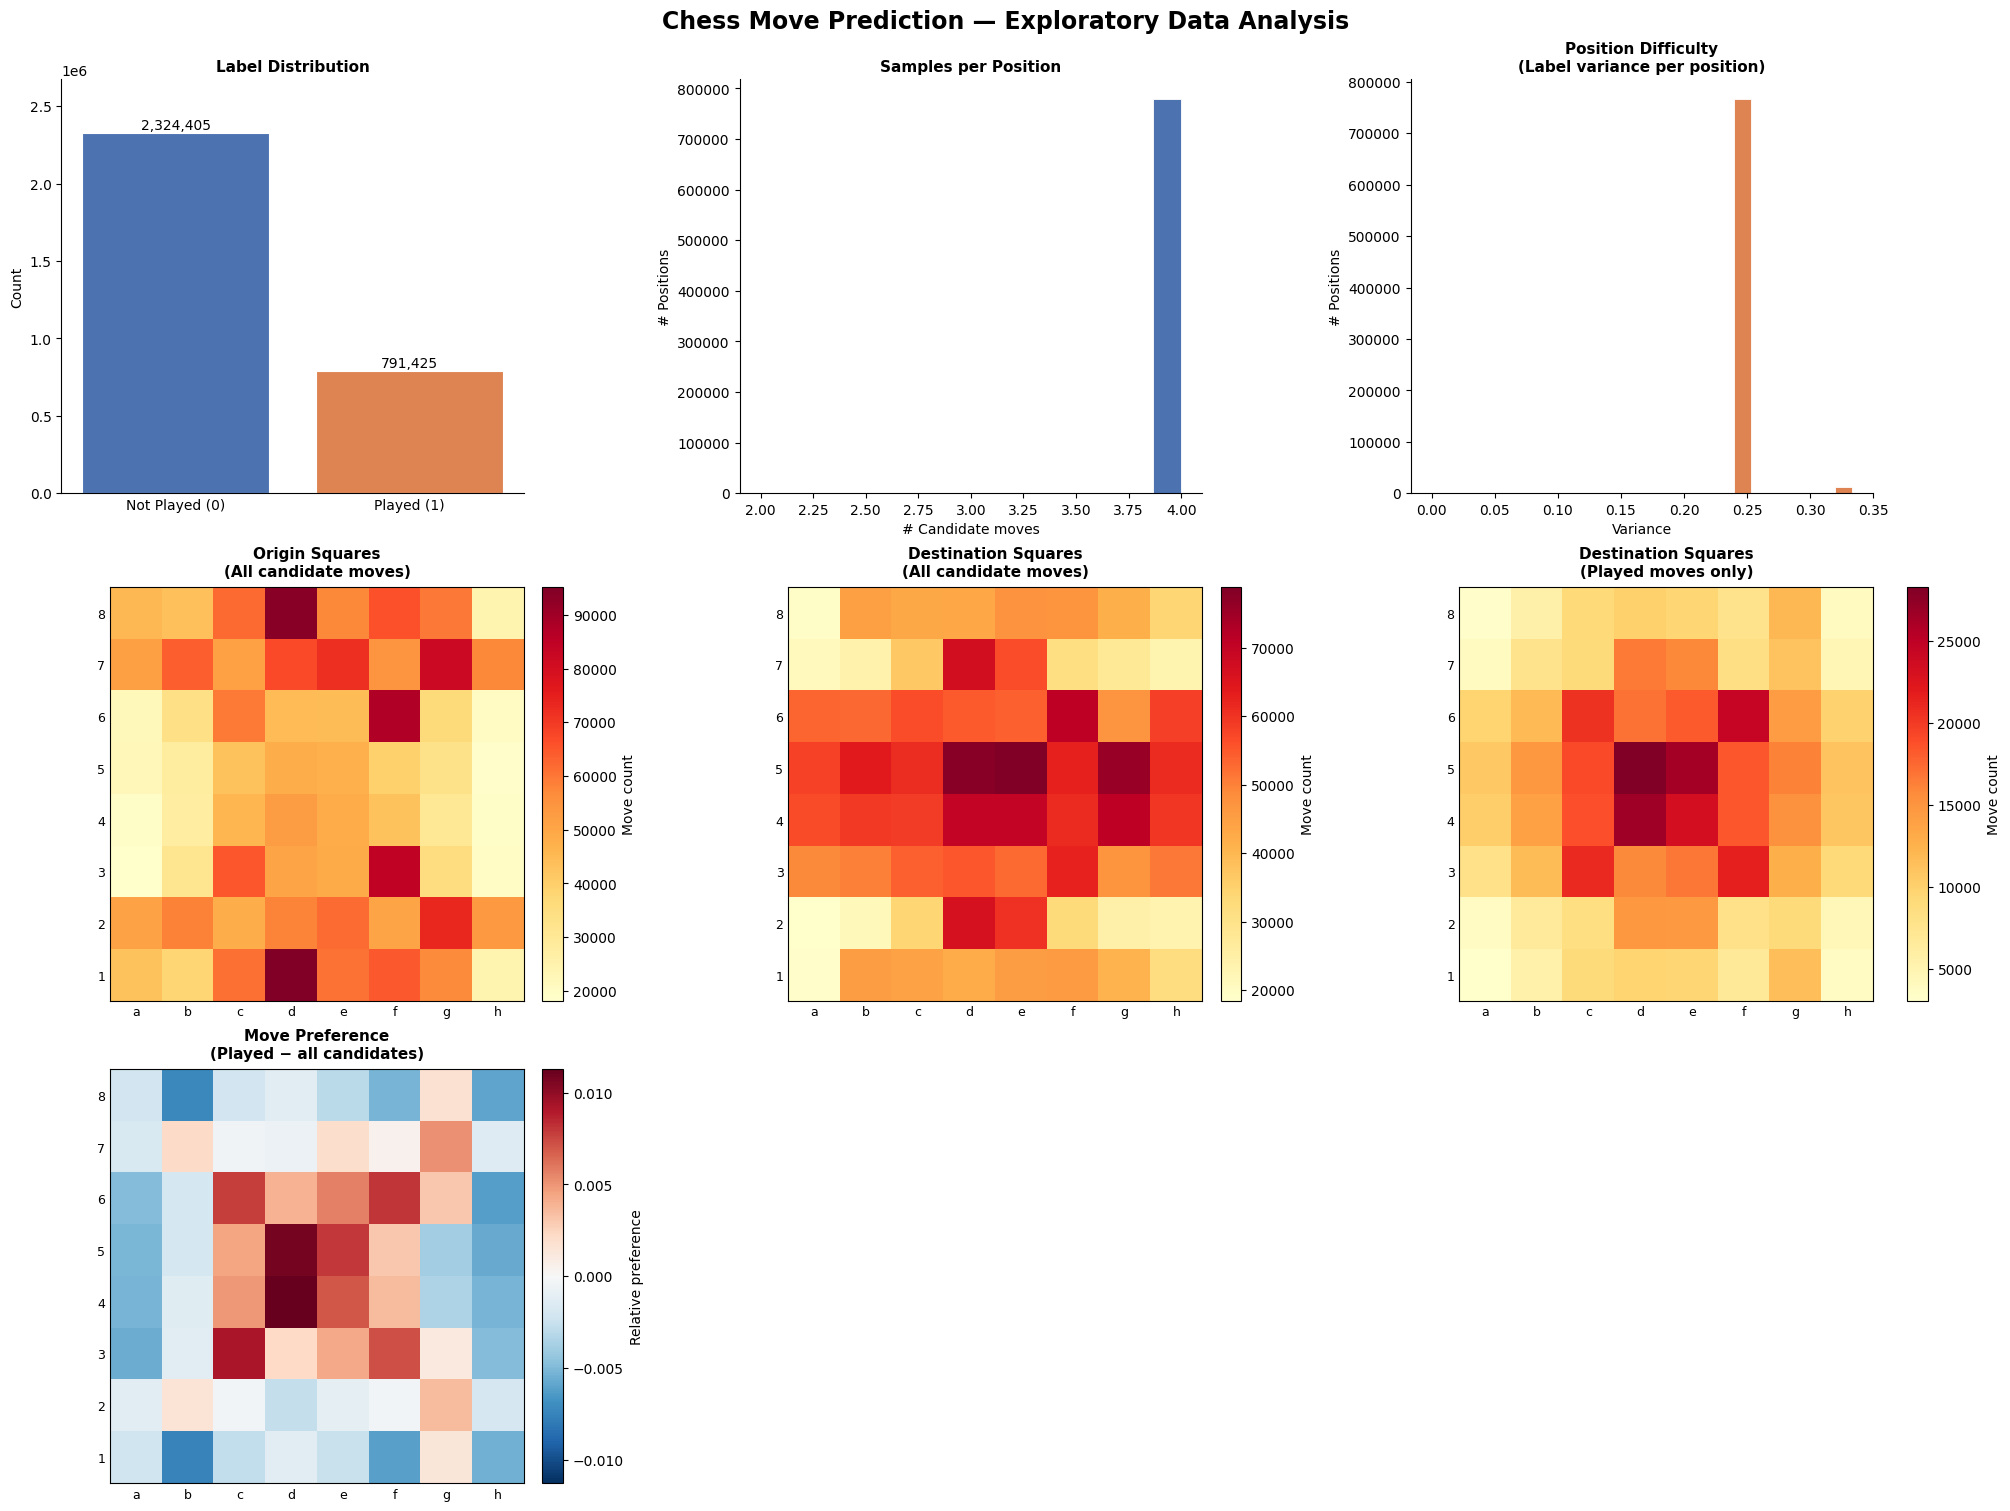

In [34]:
import matplotlib.pyplot as plt
import numpy as np

df = df_dataset_balanced

# -------------------------------
# Played moves
# -------------------------------
df_played = df[df["label"] == 1]

# -------------------------------
# Heatmap data (UPDATED LOGIC)
# -------------------------------
from_all = np.zeros((8, 8))
to_all = np.zeros((8, 8))
to_played = np.zeros((8, 8))

# Fast accumulation
np.add.at(from_all, (df["from_rank"], df["from_file"]), 1)
np.add.at(to_all, (df["to_rank"], df["to_file"]), 1)
np.add.at(to_played, (df_played["to_rank"], df_played["to_file"]), 1)

# Flip board for correct orientation
from_all = from_all[::-1]
to_all = to_all[::-1]
to_played = to_played[::-1]

# Safe probabilities
to_all_prob = to_all / max(to_all.sum(), 1)
to_played_prob = to_played / max(to_played.sum(), 1)

diff = to_played_prob - to_all_prob

# -------------------------------
# Position-level stats
# -------------------------------
samples_per_position = df.groupby("position_id").size()
pos_var = df.groupby("position_id")["label"].var()

# -------------------------------
# Feature selection
# -------------------------------
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ["label", "position_id", "game_id"]:
    if col in feature_cols:
        feature_cols.remove(col)

# -------------------------------
# Board labels
# -------------------------------
FILES = list("abcdefgh")
RANKS = list("87654321")

def style_board_ax(ax, title, im, fig, label="Move count"):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xticks(range(8)); ax.set_xticklabels(FILES, fontsize=9)
    ax.set_yticks(range(8)); ax.set_yticklabels(RANKS, fontsize=9)
    ax.tick_params(length=0)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)

# -------------------------------
# Plot
# -------------------------------
fig, axes = plt.subplots(3, 3, figsize=(20, 15), constrained_layout=True)
fig.suptitle("Chess Move Prediction — Exploratory Data Analysis",
             fontsize=17, fontweight="bold")

# ── 1. Label distribution ─────────────────────────────
ax = axes[0, 0]
counts = df["label"].value_counts().sort_index()
bars = ax.bar(["Not Played (0)", "Played (1)"], counts.values,
              color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.8)

for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + counts.max()*0.01,
            f"{v:,}", ha="center", fontsize=10)

ax.set_title("Label Distribution", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", length=0)

# ── 2. Samples per position ───────────────────────────
ax = axes[0, 1]
ax.hist(samples_per_position, bins=15, color="#4C72B0",
        edgecolor="white", linewidth=0.6)
ax.set_title("Samples per Position", fontsize=11, fontweight="bold")
ax.set_xlabel("# Candidate moves")
ax.set_ylabel("# Positions")
ax.spines[["top", "right"]].set_visible(False)

# ── 3. Position difficulty ────────────────────────────
ax = axes[0, 2]
ax.hist(pos_var.dropna(), bins=25, color="#DD8452",
        edgecolor="white", linewidth=0.6)
ax.set_title("Position Difficulty\n(Label variance per position)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Variance")
ax.set_ylabel("# Positions")
ax.spines[["top", "right"]].set_visible(False)

# ── 4. FROM heatmap ───────────────────────────────────
im1 = axes[1, 0].imshow(from_all, cmap="YlOrRd", aspect="equal")
style_board_ax(axes[1, 0],
               "Origin Squares\n(All candidate moves)", im1, fig)

# ── 5. TO heatmap (all) ───────────────────────────────
im2 = axes[1, 1].imshow(to_all, cmap="YlOrRd", aspect="equal")
style_board_ax(axes[1, 1],
               "Destination Squares\n(All candidate moves)", im2, fig)

# ── 6. TO heatmap (played) ────────────────────────────
im3 = axes[1, 2].imshow(to_played, cmap="YlOrRd", aspect="equal")
style_board_ax(axes[1, 2],
               "Destination Squares\n(Played moves only)", im3, fig)

# ── 7. Preference diff ────────────────────────────────
ax = axes[2, 0]
vmax = np.abs(diff).max()
im4 = ax.imshow(diff, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="equal")
style_board_ax(ax,
               "Move Preference\n(Played − all candidates)",
               im4, fig, label="Relative preference")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

plt.savefig("chess_eda.png", dpi=150, bbox_inches="tight")
plt.show()

---
# 10. Model Training & Evaluation

## Evaluation Approach

All models are evaluated using **three metrics**:

| Metric | Description |
|---|---|
| **Top-1 (train)** | Accuracy on train games — measures fit |
| **Top-1 (test)** | Accuracy on held-out `test_games` — true generalization |
| **Gap** | train − test; >0.05 flags overfitting |
| **Top-3 (test)** | Correct move in top-3 predictions on test games |

> `test_games` was never used during dataset creation or training — this is the honest eval.

## Evaluation Helpers


In [35]:
from scipy.sparse import csr_matrix
import numpy as np
from tqdm import tqdm

def evaluate_top1_full(games, model, max_positions=2000, feature_cols=None):
    correct = 0
    total = 0

    all_cols = get_column_names_v2()[:-1]  # drop 'label'
    if feature_cols is not None:
        col_indices = [all_cols.index(c) for c in feature_cols]
    else:
        col_indices = list(range(len(all_cols)))

    for game in tqdm(games):
        board = game.board()

        for move in game.mainline_moves():
            if total >= max_positions:
                return correct / total

            legal_moves = list(board.legal_moves)
            board_arr = board_to_array(board)
            meta_feat = get_metadata_features_fast(board)

            rows = []
            for m in legal_moves:
                full_row = board_arr + move_to_semantic_array(board, m) + meta_feat
                rows.append([full_row[i] for i in col_indices])

            batch = csr_matrix(rows, dtype=np.float32)
            probs = model.predict_proba(batch)[:, 1]
            best_move = legal_moves[np.argmax(probs)]

            if best_move == move:
                correct += 1

            total += 1
            board.push(move)

    return correct / total if total > 0 else 0.0

In [36]:
from scipy.sparse import csr_matrix
import numpy as np
from tqdm import tqdm

def evaluate_top1_full_ranker(games, model, mode="classification", max_positions=2000, feature_cols=None):
    correct = 0
    total = 0

    # get full column names (without label)
    all_cols = get_column_names_v2()[:-1]  # drop 'label'
    if feature_cols is not None:
        col_indices = [all_cols.index(c) for c in feature_cols]
    else:
        col_indices = list(range(len(all_cols)))

    for game in tqdm(games):
        board = game.board()

        for move in game.mainline_moves():
            if total >= max_positions:
                return correct / total

            legal_moves = list(board.legal_moves)
            board_arr = board_to_array(board)
            meta_feat = get_metadata_features_fast(board)

            rows = []
            for m in legal_moves:
                full_row = board_arr + move_to_semantic_array(board, m) + meta_feat
                rows.append([full_row[i] for i in col_indices])

            batch = csr_matrix(rows, dtype=np.float32)

            if mode == "classification":
                scores = model.predict_proba(batch)[:, 1]
            elif mode == "ranking":
                scores = model.predict(batch)
            else:
                raise ValueError("mode must be 'classification' or 'ranking'")

            best_move = legal_moves[np.argmax(scores)]

            if best_move == move:
                correct += 1

            total += 1
            board.push(move)

    return correct / total if total > 0 else 0.0

In [37]:
from scipy.sparse import csr_matrix
import numpy as np

def evaluate_top1_ranker_fast(games, model, max_positions=None):
    correct = 0
    total = 0

    for game in games:
        board = game.board()

        for move in game.mainline_moves():
            if max_positions and total >= max_positions:
                return correct / total

            legal_moves = list(board.legal_moves)

            board_arr = np.array(board_to_array(board), dtype=np.float32)
            meta_feat = np.array(get_metadata_features_fast(board), dtype=np.float32)

            # cache move features
            move_cache = {
                m: np.array(move_to_semantic_array(board, m), dtype=np.float32)
                for m in legal_moves
            }

            n_moves = len(legal_moves)
            feat_len = len(board_arr) + len(meta_feat) + len(next(iter(move_cache.values())))

            rows = np.empty((n_moves, feat_len), dtype=np.float32)

            for i, m in enumerate(legal_moves):
                rows[i] = np.concatenate((board_arr, move_cache[m], meta_feat))

            batch = csr_matrix(rows)

            scores = model.predict(batch)
            best_move = legal_moves[np.argmax(scores)]

            if best_move == move:
                correct += 1

            total += 1
            board.push(move)

    return correct / total if total > 0 else 0.0

In [38]:
from scipy.sparse import csr_matrix
import numpy as np

def evaluate_top1_batched(games, model, max_positions=20000, batch_size=5000):
    correct = 0
    total = 0

    batch_rows = []
    batch_meta = []   # (start_idx, num_moves, true_idx)

    for game in games:
        board = game.board()

        for move in game.mainline_moves():
            if total >= max_positions:
                break

            legal_moves = list(board.legal_moves)

            board_arr = board_to_array(board)
            meta_feat = get_metadata_features_fast(board)

            start_idx = len(batch_rows)

            true_idx = None

            for i, m in enumerate(legal_moves):
                row = board_arr + move_to_semantic_array(board, m) + meta_feat
                batch_rows.append(row)

                if m == move:
                    true_idx = i

            batch_meta.append((start_idx, len(legal_moves), true_idx))

            total += 1
            board.push(move)

            # 🔥 Run model when batch is large
            if len(batch_rows) >= batch_size:
                correct += process_batch(batch_rows, batch_meta, model)
                batch_rows.clear()
                batch_meta.clear()

        if total >= max_positions:
            break

    # process remaining
    if batch_rows:
        correct += process_batch(batch_rows, batch_meta, model)

    return correct / total


def process_batch(rows, meta, model):
    rows = np.array(rows, dtype=np.float32)
    batch = csr_matrix(rows)

    scores = model.predict(batch)

    correct = 0

    for start, length, true_idx in meta:
        group_scores = scores[start:start+length]
        pred_idx = np.argmax(group_scores)

        if pred_idx == true_idx:
            correct += 1

    return correct

In [39]:
from scipy.sparse import csr_matrix
import numpy as np
from tqdm import tqdm

def evaluate_topk_full_ranker(
    games,
    model,
    k=3,
    mode="ranking",
    max_positions=20000,
    feature_cols=None
):
    correct = 0
    total = 0

    # get full column names (without label)
    all_cols = get_column_names_v2()[:-1]  # drop 'label'

    if feature_cols is not None:
        col_indices = [all_cols.index(c) for c in feature_cols]
    else:
        col_indices = list(range(len(all_cols)))

    for game in tqdm(games):
        board = game.board()

        for move in game.mainline_moves():
            if total >= max_positions:
                return correct / total

            legal_moves = list(board.legal_moves)

            board_arr = board_to_array(board)
            meta_feat = get_metadata_features_fast(board)

            rows = []
            for m in legal_moves:
                full_row = board_arr + move_to_semantic_array(board, m) + meta_feat
                rows.append([full_row[i] for i in col_indices])

            batch = csr_matrix(rows, dtype=np.float32)

            if mode == "classification":
                scores = model.predict_proba(batch)[:, 1]
            elif mode == "ranking":
                scores = model.predict(batch)
            else:
                raise ValueError("mode must be 'classification' or 'ranking'")

            # 🔥 Top-k indices
            topk_idx = np.argsort(scores)[-k:]

            # index of true move
            true_idx = legal_moves.index(move)

            if true_idx in topk_idx:
                correct += 1

            total += 1
            board.push(move)

    return correct / total if total > 0 else 0.0

## Overfit Test Helper

In [40]:
def overfit_test(model, mode="classification", max_positions=500, feature_cols=None):
    train_top1 = evaluate_top1_full_ranker(train_games, model, mode=mode, max_positions=max_positions, feature_cols=feature_cols)
    test_top1  = evaluate_top1_full_ranker(test_games,  model, mode=mode, max_positions=max_positions, feature_cols=feature_cols)
    gap = train_top1 - test_top1
    print(f"  Train Top-1: {train_top1:.4f}")
    print(f"  Test  Top-1: {test_top1:.4f}")
    print(f"  Gap:         {gap:.4f}  {'⚠️ overfit' if gap > 0.05 else '✅ ok'}")
    return train_top1, test_top1, gap

---
## 10.1 Logistic Regression (Baseline)

Simple linear baseline. Trained on `X_train_b` / `y_train_b` (balanced dataset, 3 negatives).


In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver="saga",
    penalty="l1",
    max_iter=100,
    tol=1e-3,
    n_jobs=-1,
    verbose=1
)

model.fit(X_train_b, y_train_b)


convergence after 11 epochs took 75 seconds


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [42]:
y_pred = model.predict(X_val_b)
y_prob = model.predict_proba(X_val_b)[:, 1]


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:",  accuracy_score(y_val_b, y_pred))
print("Precision:", precision_score(y_val_b, y_pred))
print("Recall:",    recall_score(y_val_b, y_pred))
print("F1 Score:",  f1_score(y_val_b, y_pred))
print("ROC-AUC:",   roc_auc_score(y_val_b, y_prob))


Accuracy: 0.7760035691015942
Precision: 0.7028128115112903
Recall: 0.2048819932278769
F1 Score: 0.3172733587032019
ROC-AUC: 0.6654232524593795


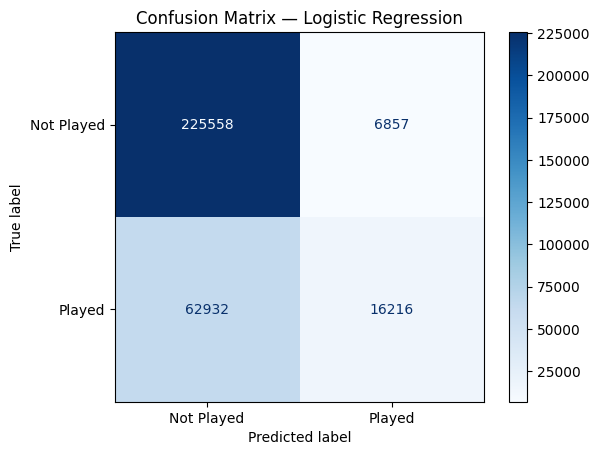

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_b, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Played", "Played"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


### Top-1 / Top-3 Ranking Accuracy

In [45]:
y_prob = model.predict_proba(X_val_b)[:, 1]

df_val = df_dataset_balanced.iloc[val_idx_b].copy()
df_val["prob"] = y_prob
df_val["rank"] = df_val.groupby("position_id")["prob"].rank(method="first", ascending=False)

top1_accuracy = (df_val[df_val["rank"] == 1]["label"] == 1).mean()
print("Val Top-1 Accuracy:", top1_accuracy)


Val Top-1 Accuracy: 0.2556552733753421


In [46]:
top3 = df_val[df_val["rank"] <= 3]
top3_accuracy = top3.groupby("position_id")["label"].max().mean()
print("Val Top-3 Accuracy:", top3_accuracy)


Val Top-3 Accuracy: 0.7499458977786264


### Overfit Test

In [47]:
print("Logistic Regression — Overfit Test")
lr_train, lr_test, lr_gap = overfit_test(model, mode="classification", feature_cols=live_feature_cols)

Logistic Regression — Overfit Test


  0%|▎                                                                                                                                                                        | 5/3000 [00:00<09:54,  5.04it/s]

  Train Top-1: 0.2360
  Test  Top-1: 0.1940
  Gap:         0.0420  ✅ ok


---
## 10.2 SGD Classifier

Online linear model — faster than Logistic Regression, useful for large-scale data.


In [48]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="log_loss",
    max_iter=5,
    n_jobs=-1
)

sgd_model.fit(X_train_b, y_train_b)

score = evaluate_top1_full(test_games, sgd_model, feature_cols=live_feature_cols)
print("SGD Test Top-1:", score)


  1%|█▍                                                                                                                                                                      | 26/3000 [00:03<07:09,  6.92it/s]

SGD Test Top-1: 0.1875


### Overfit Test

In [49]:
print("SGD Classifier — Overfit Test")
sgd_train, sgd_test, sgd_gap = overfit_test(sgd_model, mode="classification", feature_cols=live_feature_cols)


SGD Classifier — Overfit Test


  0%|▎                                                                                                                                                                        | 5/3000 [00:00<09:40,  5.16it/s]

  Train Top-1: 0.2320
  Test  Top-1: 0.1920
  Gap:         0.0400  ✅ ok


---
## 10.3 LightGBM Classifier

Gradient boosted trees with binary cross-entropy loss.


In [50]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=64,
    learning_rate=0.05,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(X_train_b, y_train_b)

score = evaluate_top1_full(test_games, lgb_model, feature_cols=live_feature_cols)
print("LightGBM Test Top-1:", score)


  1%|█▍                                                                                                                                                                      | 26/3000 [00:04<09:17,  5.34it/s]

LightGBM Test Top-1: 0.2745


### Overfit Test

In [51]:
print("LightGBM Classifier — Overfit Test")
lgb_train, lgb_test, lgb_gap = overfit_test(lgb_model, mode="classification", feature_cols=live_feature_cols)


LightGBM Classifier — Overfit Test


  0%|▎                                                                                                                                                                        | 5/3000 [00:01<12:28,  4.00it/s]

  Train Top-1: 0.3440
  Test  Top-1: 0.2780
  Gap:         0.0660  ⚠️ overfit


---
## 10.4 XGBoost Classifier

Alternative gradient boosting implementation.


In [52]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    tree_method="hist",
    n_jobs=-1
)

xgb_model.fit(X_train_b, y_train_b)

score = evaluate_top1_full(test_games, xgb_model, feature_cols=live_feature_cols)
print("XGBoost Test Top-1:", score)


  1%|█▍                                                                                                                                                                      | 26/3000 [00:04<09:07,  5.43it/s]

XGBoost Test Top-1: 0.2575


### Overfit Test

In [53]:
print("XGBoost Classifier — Overfit Test")
xgb_train, xgb_test, xgb_gap = overfit_test(xgb_model, mode="classification", feature_cols=live_feature_cols)


XGBoost Classifier — Overfit Test


  0%|▎                                                                                                                                                                        | 5/3000 [00:01<11:46,  4.24it/s]

  Train Top-1: 0.3280
  Test  Top-1: 0.2540
  Gap:         0.0740  ⚠️ overfit


---
## 10.5 LightGBM Ranker — v1 (LambdaRank)

Reframes the problem as **learning-to-rank**. Directly optimizes move ranking (NDCG).  
Trained on `X_train_r` / `y_train_r` / `group_train_r` (ranker dataset, 15 negatives).


In [55]:
import lightgbm as lgb

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=300,
    num_leaves=128,
    learning_rate=0.03,
    verbosity=-1,
    n_jobs=-1
)

ranker.fit(
    X_train_r,
    y_train_r,
    group=group_train_r
)


,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.03
,n_estimators,300
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Top-1 / Top-3 Accuracy

In [56]:
top1 = evaluate_top1_full_ranker(test_games, ranker, mode="ranking", max_positions=2000, feature_cols=live_feature_cols)
print("Ranker v1 — Test Top-1:", top1)


  1%|█▍                                                                                                                                                                      | 26/3000 [00:04<09:24,  5.27it/s]

Ranker v1 — Test Top-1: 0.2805


In [57]:
top3 = evaluate_topk_full_ranker(test_games, ranker, k=3, mode="ranking", max_positions=2000, feature_cols=live_feature_cols)
print("Ranker v1 — Test Top-3:", top3)


  1%|█▍                                                                                                                                                                      | 26/3000 [00:04<09:27,  5.24it/s]

Ranker v1 — Test Top-3: 0.4775


### Overfit Test

In [58]:
print("LightGBM Ranker v1 — Overfit Test")
ranker_v1_train, ranker_v1_test, ranker_v1_gap = overfit_test(ranker, mode="ranking", feature_cols=live_feature_cols)


LightGBM Ranker v1 — Overfit Test


  0%|▎                                                                                                                                                                        | 5/3000 [00:01<12:45,  3.91it/s]

  Train Top-1: 0.3440
  Test  Top-1: 0.2880
  Gap:         0.0560  ⚠️ overfit


---
## 10.6 LightGBM Ranker — v2 (Tuned)

More estimators, more leaves, added regularization (`min_data_in_leaf`, `feature_fraction`, `bagging_fraction`).


In [59]:
ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=400,
    num_leaves=256,
    learning_rate=0.03,
    min_data_in_leaf=30,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    verbosity=-1,
    n_jobs=-1
)

ranker.fit(X_train_r, y_train_r, group=group_train_r)


,boosting_type,'gbdt'
,num_leaves,256
,max_depth,-1
,learning_rate,0.03
,n_estimators,400
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Overfit Test

In [60]:
print("LightGBM Ranker v2 — Overfit Test")
ranker_v2_train, ranker_v2_test, ranker_v2_gap = overfit_test(ranker, mode="ranking", feature_cols=live_feature_cols)


LightGBM Ranker v2 — Overfit Test


  0%|▎                                                                                                                                                                        | 5/3000 [00:01<13:15,  3.77it/s]

  Train Top-1: 0.3540
  Test  Top-1: 0.3220
  Gap:         0.0320  ✅ ok


---
## 10.7 LightGBM Ranker — v3 (HyperParameter Tuned)

### HyperParameter Tuning

In [100]:
from sklearn.model_selection import ParameterSampler
param_dist = {
    "num_leaves": [32, 64, 128],
    "learning_rate": [0.01, 0.03, 0.05],
    "min_data_in_leaf": [50, 80, 120],
    "feature_fraction": [0.5, 0.6, 0.7],
    "bagging_fraction": [0.5, 0.6, 0.7],
    "n_estimators": [200, 300, 400],
}

In [102]:
from tqdm import tqdm
from sklearn.model_selection import ParameterSampler
import numpy as np
import pandas as pd
import lightgbm as lgb
import time

# -------------------------------
# Setup
# -------------------------------
best_score = -np.inf
best_params = None
best_model = None
results = []

param_list = list(ParameterSampler(param_dist, n_iter=20, random_state=42))

start_time = time.time()

# -------------------------------
# Tuning loop
# -------------------------------
for i, params in enumerate(tqdm(param_list, desc="Hyperparameter Tuning"), 1):
    
    iter_start = time.time()
    
    ranker = lgb.LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        verbosity=-1,
        n_jobs=-1,
        **params
    )
    
    ranker.fit(
        X_train_r,
        y_train_r,
        group=group_train_r,
        eval_set=[(X_val_r, y_val_r)],
        eval_group=[group_val_r],
        eval_at=[1],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    
    # -------------------------------
    # Safe score extraction
    # -------------------------------
    score = ranker.best_score_.get("valid_0", {}).get("ndcg@1", -np.inf)
    
    iter_time = time.time() - iter_start
    
    # -------------------------------
    # Store results
    # -------------------------------
    results.append({
        "iter": i,
        "score": score,
        "time_sec": round(iter_time, 2),
        **params
    })
    
    # -------------------------------
    # Logging
    # -------------------------------
    tqdm.write(
        f"[{i}/{len(param_list)}] "
        f"NDCG@1={score:.5f} | "
        f"time={iter_time:.1f}s"
    )
    
    # -------------------------------
    # Track best
    # -------------------------------
    if score > best_score:
        best_score = score
        best_params = params
        best_model = ranker
        
        tqdm.write(f"🔥 NEW BEST → {best_score:.5f}")

# -------------------------------
# Final output
# -------------------------------
total_time = time.time() - start_time

print("\n==============================")
print(f"Best NDCG@1: {best_score:.5f}")
print(f"Best params: {best_params}")
print(f"Total time: {total_time/60:.2f} minutes")

# -------------------------------
# Results dataframe (IMPORTANT)
# -------------------------------
df_results = pd.DataFrame(results).sort_values("score", ascending=False)

print("\nTop 5 configs:")
display(df_results.head())

Hyperparameter Tuning:   5%|███████▍                                                                                                                                            | 1/20 [00:37<11:51, 37.46s/it]

[1/20] NDCG@1=0.36796 | time=37.5s
🔥 NEW BEST → 0.36796


Hyperparameter Tuning:  10%|██████████████▊                                                                                                                                     | 2/20 [01:28<13:34, 45.23s/it]

[2/20] NDCG@1=0.39713 | time=50.7s
🔥 NEW BEST → 0.39713


Hyperparameter Tuning:  15%|██████████████████████▏                                                                                                                             | 3/20 [02:28<14:43, 51.98s/it]

[3/20] NDCG@1=0.41263 | time=60.0s
🔥 NEW BEST → 0.41263


Hyperparameter Tuning:  20%|█████████████████████████████▌                                                                                                                      | 4/20 [03:22<14:08, 53.05s/it]

[4/20] NDCG@1=0.38560 | time=54.7s


Hyperparameter Tuning:  25%|█████████████████████████████████████                                                                                                               | 5/20 [04:16<13:20, 53.35s/it]

[5/20] NDCG@1=0.39619 | time=53.9s


Hyperparameter Tuning:  30%|████████████████████████████████████████████▍                                                                                                       | 6/20 [05:32<14:12, 60.86s/it]

[6/20] NDCG@1=0.38227 | time=75.5s


Hyperparameter Tuning:  35%|███████████████████████████████████████████████████▊                                                                                                | 7/20 [06:11<11:39, 53.79s/it]

[7/20] NDCG@1=0.36612 | time=39.2s


Hyperparameter Tuning:  40%|███████████████████████████████████████████████████████████▏                                                                                        | 8/20 [06:50<09:50, 49.23s/it]

[8/20] NDCG@1=0.33456 | time=39.5s


Hyperparameter Tuning:  45%|██████████████████████████████████████████████████████████████████▌                                                                                 | 9/20 [07:52<09:42, 52.97s/it]

[9/20] NDCG@1=0.39235 | time=61.2s


Hyperparameter Tuning:  50%|█████████████████████████████████████████████████████████████████████████▌                                                                         | 10/20 [08:32<08:09, 48.96s/it]

[10/20] NDCG@1=0.33456 | time=40.0s


Hyperparameter Tuning:  55%|████████████████████████████████████████████████████████████████████████████████▊                                                                  | 11/20 [09:23<07:27, 49.70s/it]

[11/20] NDCG@1=0.37864 | time=51.4s


Hyperparameter Tuning:  60%|████████████████████████████████████████████████████████████████████████████████████████▏                                                          | 12/20 [10:19<06:53, 51.72s/it]

[12/20] NDCG@1=0.40398 | time=56.3s


Hyperparameter Tuning:  65%|███████████████████████████████████████████████████████████████████████████████████████████████▌                                                   | 13/20 [11:11<06:01, 51.66s/it]

[13/20] NDCG@1=0.38232 | time=51.5s


Hyperparameter Tuning:  70%|██████████████████████████████████████████████████████████████████████████████████████████████████████▉                                            | 14/20 [11:52<04:50, 48.50s/it]

[14/20] NDCG@1=0.37796 | time=41.2s


Hyperparameter Tuning:  75%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 15/20 [12:44<04:07, 49.56s/it]

[15/20] NDCG@1=0.37061 | time=52.0s


Hyperparameter Tuning:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                             | 16/20 [13:57<03:46, 56.64s/it]

[16/20] NDCG@1=0.38412 | time=73.1s


Hyperparameter Tuning:  85%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                      | 17/20 [14:52<02:48, 56.27s/it]

[17/20] NDCG@1=0.41546 | time=55.4s
🔥 NEW BEST → 0.41546


Hyperparameter Tuning:  90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎              | 18/20 [15:47<01:51, 55.83s/it]

[18/20] NDCG@1=0.36981 | time=54.8s


Hyperparameter Tuning:  95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋       | 19/20 [16:39<00:54, 54.56s/it]

[19/20] NDCG@1=0.37864 | time=51.6s


Hyperparameter Tuning: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [17:22<00:00, 52.13s/it]

[20/20] NDCG@1=0.37651 | time=43.1s

Best NDCG@1: 0.41546
Best params: {'num_leaves': 128, 'n_estimators': 300, 'min_data_in_leaf': 50, 'learning_rate': 0.05, 'feature_fraction': 0.7, 'bagging_fraction': 0.6}
Total time: 17.38 minutes

Top 5 configs:


,iter,score,time_sec,num_leaves,n_estimators,min_data_in_leaf,learning_rate,feature_fraction,bagging_fraction
16,17,0.415463,55.42,128,300,50,0.05,0.7,0.6
2,3,0.412632,60.00,128,300,50,0.05,0.5,0.6
11,12,0.403984,56.31,64,400,50,0.05,0.7,0.7
1,2,0.397128,50.67,64,300,80,0.05,0.6,0.5
4,5,0.396193,53.87,128,200,50,0.03,0.5,0.7


In [103]:
param_dist_aggressive = {
    "num_leaves": [31, 63, 127, 255],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "min_data_in_leaf": [30, 50, 80, 120],
    "feature_fraction": [0.5, 0.6, 0.7, 0.8],
    "bagging_fraction": [0.5, 0.6, 0.7, 0.8],
    "lambda_l1": [0, 0.1, 0.5, 1],
    "lambda_l2": [0, 0.1, 0.5, 1],
    "n_estimators": [200, 300, 500],
}

In [106]:
# =========================================================
# 🔥 RANKER HYPERPARAMETER TUNING (ALIGNED WITH TOP-1)
# =========================================================

from tqdm import tqdm
from sklearn.model_selection import ParameterSampler
import numpy as np
import pandas as pd
import lightgbm as lgb
import time

# -------------------------------
# SUBSAMPLE TRAINING BY POSITION
# -------------------------------
train_pos_ids = position_ids_ranker[train_idx_r]
unique_positions = np.unique(train_pos_ids)

sample_frac = 0.2   # adjust (0.1–0.3 depending on speed)
sample_size = int(sample_frac * len(unique_positions))

sampled_positions = np.random.choice(unique_positions, size=sample_size, replace=False)
mask = np.isin(train_pos_ids, sampled_positions)

X_train_small = X_train_r[mask]
y_train_small = y_train_r[mask]
groups_small_ids = train_pos_ids[mask]

# sort by position_id (CRITICAL)
order = np.argsort(groups_small_ids)

X_train_small = X_train_small[order]
y_train_small = y_train_small[order]
groups_small_ids = groups_small_ids[order]

group_train_small = build_groups(groups_small_ids)

print("Subsampled rows:", X_train_small.shape)
print("Subsampled groups:", len(group_train_small))


# -------------------------------
# HYPERPARAM SEARCH SETUP
# -------------------------------
param_list = list(ParameterSampler(param_dist_aggressive, n_iter=20, random_state=42))

best_score = -np.inf          # based on TOP-1
best_params = None
best_model = None
results = []

start_time = time.time()

# -------------------------------
# BUILD val_games (REQUIRED)
# -------------------------------
val_game_ids = set(game_ids_ranker[val_idx_r])

val_games = [
    game for game_id, game in enumerate(games)
    if game_id in val_game_ids
]

print(f"Validation games: {len(val_games)}")

# -------------------------------
# TUNING LOOP
# -------------------------------
for i, params in enumerate(tqdm(param_list, desc="Hyperparameter Tuning"), 1):
    
    iter_start = time.time()
    
    ranker = lgb.LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        verbosity=-1,
        n_jobs=-1,
        **params
    )
    
    ranker.fit(
        X_train_small,
        y_train_small,
        group=group_train_small,
        eval_set=[(X_val_r, y_val_r)],
        eval_group=[group_val_r],
        eval_at=[1],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    
    # -------------------------------
    # NDCG score (fast proxy)
    # -------------------------------
    ndcg_score = ranker.best_score_.get("valid_0", {}).get("ndcg@1", -np.inf)
    
    # -------------------------------
    # REAL metric (Top-1 accuracy)
    # -------------------------------
    top1_score = evaluate_top1_full_ranker(
        val_games,
        ranker,
        mode="ranking",
        max_positions=300,   # keep small for speed
        feature_cols = live_feature_cols
    )
    
    iter_time = time.time() - iter_start
    
    # -------------------------------
    # Store results
    # -------------------------------
    results.append({
        "iter": i,
        "ndcg@1": ndcg_score,
        "top1": top1_score,
        "time_sec": round(iter_time, 2),
        **params
    })
    
    tqdm.write(
        f"[{i}/{len(param_list)}] "
        f"NDCG@1={ndcg_score:.5f} | "
        f"Top1={top1_score:.5f} | "
        f"time={iter_time:.1f}s"
    )
    
    # -------------------------------
    # Select BEST based on Top-1
    # -------------------------------
    if top1_score > best_score:
        best_score = top1_score
        best_params = params
        best_model = ranker
        
        tqdm.write(f"🔥 NEW BEST TOP1 → {best_score:.5f}")


# -------------------------------
# RESULTS
# -------------------------------
total_time = time.time() - start_time

print("\n==============================")
print(f"Best TOP-1: {best_score:.5f}")
print(f"Best params: {best_params}")
print(f"Total time: {total_time/60:.2f} minutes")

df_results = pd.DataFrame(results).sort_values("top1", ascending=False)

print("\nTop configs:")
display(df_results.head())


# -------------------------------
# FINAL TRAIN ON FULL DATA
# -------------------------------
print("\nTraining final model on full dataset...")

final_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    verbosity=-1,
    n_jobs=-1,
    **best_params
)

final_ranker.fit(
    X_train_r,
    y_train_r,
    group=group_train_r
)

print("✅ Final model trained on full data")

Subsampled rows: (1095395, 762)
Subsampled groups: 68549
Validation games: 500


Hyperparameter Tuning:   5%|███████▍                                                                                                                                            | 1/20 [00:20<06:36, 20.86s/it]

[1/20] NDCG@1=0.39635 | Top1=0.29667 | time=20.9s
🔥 NEW BEST TOP1 → 0.29667



Hyperparameter Tuning:  10%|██████████████▊                                                                                                                                     | 2/20 [00:38<05:43, 19.07s/it]

[2/20] NDCG@1=0.36064 | Top1=0.27667 | time=17.8s



Hyperparameter Tuning:  15%|██████████████████████▏                                                                                                                             | 3/20 [01:02<06:02, 21.32s/it]

[3/20] NDCG@1=0.39321 | Top1=0.30333 | time=24.0s
🔥 NEW BEST TOP1 → 0.30333



Hyperparameter Tuning:  20%|█████████████████████████████▌                                                                                                                      | 4/20 [01:18<05:08, 19.27s/it]

[4/20] NDCG@1=0.37664 | Top1=0.29667 | time=16.1s



Hyperparameter Tuning:  25%|█████████████████████████████████████                                                                                                               | 5/20 [01:32<04:17, 17.13s/it]

[5/20] NDCG@1=0.37194 | Top1=0.30000 | time=13.4s



Hyperparameter Tuning:  30%|████████████████████████████████████████████▍                                                                                                       | 6/20 [01:45<03:41, 15.82s/it]

[6/20] NDCG@1=0.37370 | Top1=0.28667 | time=13.3s



Hyperparameter Tuning:  35%|███████████████████████████████████████████████████▊                                                                                                | 7/20 [02:00<03:24, 15.72s/it]

[7/20] NDCG@1=0.39217 | Top1=0.30000 | time=15.5s



Hyperparameter Tuning:  40%|███████████████████████████████████████████████████████████▏                                                                                        | 8/20 [02:21<03:27, 17.29s/it]

[8/20] NDCG@1=0.39279 | Top1=0.28667 | time=20.7s



Hyperparameter Tuning:  45%|██████████████████████████████████████████████████████████████████▌                                                                                 | 9/20 [02:37<03:06, 16.97s/it]

[9/20] NDCG@1=0.38380 | Top1=0.30667 | time=16.3s
🔥 NEW BEST TOP1 → 0.30667



Hyperparameter Tuning:  50%|█████████████████████████████████████████████████████████████████████████▌                                                                         | 10/20 [03:02<03:12, 19.29s/it]

[10/20] NDCG@1=0.40575 | Top1=0.34000 | time=24.5s
🔥 NEW BEST TOP1 → 0.34000



Hyperparameter Tuning:  55%|████████████████████████████████████████████████████████████████████████████████▊                                                                  | 11/20 [03:26<03:07, 20.87s/it]

[11/20] NDCG@1=0.40585 | Top1=0.34000 | time=24.5s



Hyperparameter Tuning:  60%|████████████████████████████████████████████████████████████████████████████████████████▏                                                          | 12/20 [03:48<02:48, 21.04s/it]

[12/20] NDCG@1=0.39360 | Top1=0.33000 | time=21.4s



Hyperparameter Tuning:  65%|███████████████████████████████████████████████████████████████████████████████████████████████▌                                                   | 13/20 [04:04<02:18, 19.75s/it]

[13/20] NDCG@1=0.37326 | Top1=0.29333 | time=16.8s



Hyperparameter Tuning:  70%|██████████████████████████████████████████████████████████████████████████████████████████████████████▉                                            | 14/20 [04:19<01:49, 18.30s/it]

[14/20] NDCG@1=0.38461 | Top1=0.29333 | time=15.0s



Hyperparameter Tuning:  75%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                    | 15/20 [04:33<01:24, 16.87s/it]

[15/20] NDCG@1=0.35594 | Top1=0.28000 | time=13.5s



Hyperparameter Tuning:  80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                             | 16/20 [04:55<01:13, 18.36s/it]

[16/20] NDCG@1=0.38453 | Top1=0.28667 | time=21.8s



Hyperparameter Tuning:  85%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                      | 17/20 [05:22<01:03, 21.03s/it]

[17/20] NDCG@1=0.39970 | Top1=0.32000 | time=27.2s



Hyperparameter Tuning:  90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎              | 18/20 [05:48<00:44, 22.37s/it]

[18/20] NDCG@1=0.40432 | Top1=0.34333 | time=25.5s
🔥 NEW BEST TOP1 → 0.34333



Hyperparameter Tuning:  95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋       | 19/20 [05:56<00:18, 18.05s/it]

[19/20] NDCG@1=0.32708 | Top1=0.25000 | time=8.0s



Hyperparameter Tuning: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [06:07<00:00, 18.39s/it]

[20/20] NDCG@1=0.35264 | Top1=0.28667 | time=11.8s

Best TOP-1: 0.34333
Best params: {'num_leaves': 255, 'n_estimators': 300, 'min_data_in_leaf': 120, 'learning_rate': 0.05, 'lambda_l2': 0, 'lambda_l1': 0.1, 'feature_fraction': 0.5, 'bagging_fraction': 0.8}
Total time: 6.13 minutes

Top configs:


,iter,ndcg@1,top1,time_sec,num_leaves,n_estimators,min_data_in_leaf,learning_rate,lambda_l2,lambda_l1,feature_fraction,bagging_fraction
17,18,0.404322,0.343333,25.50,255,300,120,0.05,0.0,0.1,0.5,0.8
10,11,0.405854,0.340000,24.46,255,300,50,0.05,0.1,0.1,0.7,0.8
9,10,0.405750,0.340000,24.47,255,300,30,0.05,0.1,0.1,0.8,0.8
11,12,0.393595,0.330000,21.43,255,200,120,0.02,1.0,0.0,0.6,0.6
16,17,0.399699,0.320000,27.22,255,300,80,0.03,1.0,0.5,0.6,0.5



Training final model on full dataset...
✅ Final model trained on full data


### Training

In [107]:
ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    
    # tuned params
    n_estimators=300,
    num_leaves=255,
    learning_rate=0.05,
    min_data_in_leaf=120,
    feature_fraction=0.5,
    bagging_fraction=0.8,
    
    # regularization
    lambda_l1=0.1,
    lambda_l2=0.0,
    
    # others
    bagging_freq=1,
    verbosity=-1,
    n_jobs=-1
)

ranker.fit(
    X_train_r,
    y_train_r,
    group=group_train_r
)

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Top-1 / Top-3 Accuracy

In [108]:
top1_v3 = evaluate_top1_full_ranker(test_games, ranker, mode="ranking", max_positions=2000, feature_cols=live_feature_cols)
top3_v3 = evaluate_topk_full_ranker(test_games, ranker, k=3, mode="ranking", max_positions=2000, feature_cols=live_feature_cols)
print(f"Ranker v3 — Test Top-1: {top1_v3:.4f}  |  Top-3: {top3_v3:.4f}")


  1%|█▍                                                                                                                                                                      | 26/3000 [00:05<11:06,  4.46it/s]

Ranker v3 — Test Top-1: 0.3195  |  Top-3: 0.5440


### Overfit Test

In [109]:
print("LightGBM Ranker v3 — Overfit Test")
ranker_v3_train, ranker_v3_test, ranker_v3_gap = overfit_test(ranker, mode="ranking", feature_cols=live_feature_cols)


LightGBM Ranker v3 — Overfit Test


  0%|▎                                                                                                                                                                        | 5/3000 [00:01<13:10,  3.79it/s]

  Train Top-1: 0.3820
  Test  Top-1: 0.3320
  Gap:         0.0500  ✅ ok


---
# 11. Model Comparison

Summary of all models evaluated on `test_games` (game-level held-out set, never seen during training).


In [110]:
import pandas as pd

results = pd.DataFrame([
    {"Model": "Logistic Regression",    "Train Top-1": lr_train,        "Test Top-1": lr_test,        "Gap": lr_gap},
    {"Model": "SGD Classifier",         "Train Top-1": sgd_train,       "Test Top-1": sgd_test,       "Gap": sgd_gap},
    {"Model": "LightGBM Classifier",    "Train Top-1": lgb_train,       "Test Top-1": lgb_test,       "Gap": lgb_gap},
    {"Model": "XGBoost Classifier",     "Train Top-1": xgb_train,       "Test Top-1": xgb_test,       "Gap": xgb_gap},
    {"Model": "LightGBM Ranker v1",     "Train Top-1": ranker_v1_train, "Test Top-1": ranker_v1_test, "Gap": ranker_v1_gap},
    {"Model": "LightGBM Ranker v2",     "Train Top-1": ranker_v2_train, "Test Top-1": ranker_v2_test, "Gap": ranker_v2_gap},
    {"Model": "LightGBM Ranker v3",     "Train Top-1": ranker_v3_train, "Test Top-1": ranker_v3_test, "Gap": ranker_v3_gap},
])

results = results.sort_values("Test Top-1", ascending=False).reset_index(drop=True)
results["Gap Flag"] = results["Gap"].apply(lambda g: "⚠️" if g > 0.05 else "✅")

print(results.to_string(index=False))


              Model  Train Top-1  Test Top-1   Gap Gap Flag
 LightGBM Ranker v3        0.382       0.332 0.050        ✅
 LightGBM Ranker v2        0.354       0.322 0.032        ✅
 LightGBM Ranker v1        0.344       0.288 0.056       ⚠️
LightGBM Classifier        0.344       0.278 0.066       ⚠️
 XGBoost Classifier        0.328       0.254 0.074       ⚠️
Logistic Regression        0.236       0.194 0.042        ✅
     SGD Classifier        0.232       0.192 0.040        ✅


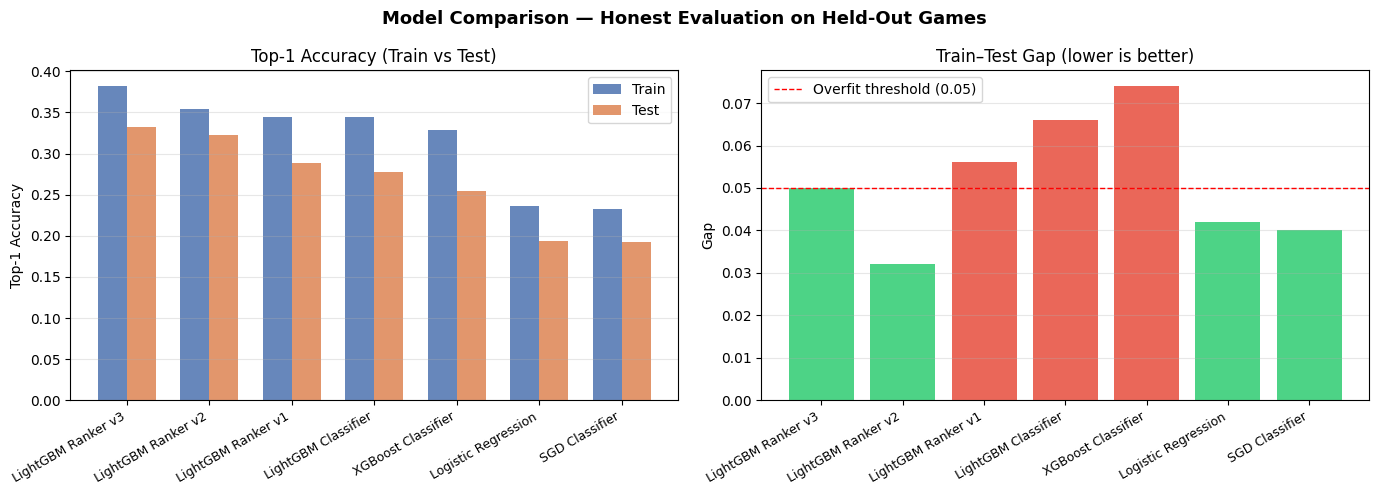

In [111]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison — Honest Evaluation on Held-Out Games", fontsize=13, fontweight="bold")

models = results["Model"].tolist()
x = np.arange(len(models))
w = 0.35

# Top-1: train vs test
ax = axes[0]
ax.bar(x - w/2, results["Train Top-1"], w, label="Train", color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, results["Test Top-1"],  w, label="Test",  color="#DD8452", alpha=0.85)
ax.set_title("Top-1 Accuracy (Train vs Test)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Top-1 Accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Gap
ax = axes[1]
colors = ["#e74c3c" if g > 0.05 else "#2ecc71" for g in results["Gap"]]
ax.bar(x, results["Gap"], color=colors, alpha=0.85)
ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="Overfit threshold (0.05)")
ax.set_title("Train–Test Gap (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Gap")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


---
# 12. Save Best Model

In [113]:
import pickle

with open("lgbm_ranker_optimized.pkl", "wb") as f:
    pickle.dump(ranker, f)

---
# 13. Summary & Next Steps

## What was built

| Component | Detail |
|---|---|
| **Data** | Lichess Elite 2019-10, ELO 2200–2600, 15k games |
| **Split** | Game-level 80/20 — no position leakage |
| **Features** | 768 board + 24 semantic move + 10 metadata (dead features dropped) |
| **Datasets** | `df_ranker` (15 neg) for ranker · `df_dataset_balanced` (3 neg) for classifiers |
| **Models** | Logistic Regression → SGD → LightGBM Classifier → XGBoost → LightGBM Ranker (v1/v2/v3) |
| **Evaluation** | Honest Top-1 / Top-3 on held-out `test_games` + overfit gap per model |

## Next Steps

1. **More data** — increase `max_games` to `len(train_games)` for full training
2. **Early stopping** — add val set to ranker fit to find optimal tree count
3. **More negatives** — increase to 25–29 (closer to full legal move set)
4. **New features** — attacked/defended squares, center control, mobility after move
5. **Neural approach** — transformer or CNN on raw board state
6. **ELO conditioning** — separate models or ELO as a feature
